In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import numpy as np 
from fiftyone import ViewField

In [3]:
import sys
%load_ext autoreload
%autoreload 2

In [4]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [5]:
dataset = fo.load_dataset('tiles_merged')


In [10]:
positive = dataset.match(
    ViewField("type_label").contains_str("positive")
)

In [8]:
positive_wp = dataset.match(
    ViewField("type_label").contains_str("positive")
)


In [ ]:
new_ds = fo.Dataset("wp_final_test", persistent=True)
new_ds.add_collection(
    positive
)
new_ds.add_collection(
    positive_wp
)

In [12]:
new_ds

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.In

In [13]:
new_ds.count_values("tags")

{'val_0': 42, 'train_0': 379, 'test_0': 55}

In [17]:
new_ds.untag_samples("train_0")

In [24]:
session = fo.launch_app(new_ds,auto=False, port=5151)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


# Composing the test set for Object Detection

In [8]:
positive = dataset.match(
    ViewField("type_label").contains_str("positive")
)
session.view = positive

In [19]:
new_ds.match_tags("test_0").count_values("parent_name")

{'FPLAN_M4_UM_M46_F1_2025_P_3-699848dc6accc_26_03_10': 11,
 'FPLAN_P4P_UM_M33_F1_2025_GSP-697b1d86c5e8c_26_03_09': 15,
 'FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10': 8,
 'FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09': 2,
 'FPLAN_P4_UM_M35_F1_2025_GSP-69970e580c6f4_26_03_10': 13,
 'UM_M3': 6}

In [18]:
new_ds.count_values("parent_name")

{'FRIWEN_M11': 49,
 'FPLAN_M4_UM_M40_F1_2025_P_4-69983ff2b2579_26_03_10': 3,
 'FPLAN_P4_UM_M35_F1_2025_GSP-69970e580c6f4_26_03_10': 13,
 'FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_26_03_09': 16,
 'FPLAN_M4_UM_M40_F1_2025_P_2-699839d1afc67_26_03_10': 8,
 'FRIWEN_M19': 3,
 'FRIWEN_M8': 54,
 'FPLAN_M4_UM_M4_F1_2025_P-69723dd2b68b6_26_03_09': 3,
 'UM_M1': 26,
 'FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_26_03_09': 2,
 'FPLAN_M4_UM_M40_F1_2025_P_1-69983452bef98_26_03_10': 1,
 'UM_M5': 67,
 'UM_M6': 18,
 'MANTASANDY_M5': 4,
 'FRIWEN_M53': 10,
 'FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10': 8,
 'GAM_M10': 8,
 'FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_26_03_10': 22,
 'GAM_M2': 23,
 'FPLAN_M4_UM_M46_F1_2025_P_3-699848dc6accc_26_03_10': 11,
 'FPLAN_P4P_UM_M33_F1_2025_GSP-697b1d86c5e8c_26_03_09': 15,
 'FRIWEN_M12': 23,
 'UM_M3': 6,
 'FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_26_03_10': 8,
 'GAM_M1': 28,
 'FPLAN_M4_UM_M13_F1_2025_P_3-6973996330251_26_03_09': 2,
 'FPLAN_M4_UM_M13_F1_2025_P_

In [27]:
val_val = new_ds.match(
    ViewField("parent_name").contains_str(
        ["GAM_M10","FRIWEN_M19",
         "FPLAN_M4_UM_M40_F1_2025_P_4-69983ff2b2579_26_03_10","FPLAN_M4_UM_M13_F1_2025_P_3-6973996330251_26_03_09"]
    )
)
val_val

Dataset:     wp_final_test
Media type:  image
Num samples: 16
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.IntField
    n_boxes_written:  fiftyo

In [29]:
val_val.tag_samples("val_0")

In [32]:
session.view = new_ds.match_tags(["test_0","val_0"],bool=False)

In [28]:
session.view = val_val

In [20]:
test_test = positive.match(
    ViewField("parent_name").contains_str(
        ["FPLAN_M4_UM_M46_F1_2025_P_3-699848dc6accc_26_03_10","FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10",
         "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09","UM_M3"]
    )
)
session.view = test_test

In [33]:
session.freeze

<bound method Session.freeze of Dataset:          wp_final_test
Media type:       image
Num samples:      405
Selected samples: 8
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. MatchTags(tags=['test_0', 'val_0'], bool=False, all=False)>

In [37]:
session.selected

['6a33d1a619d8f6f6ef56935c',
 '6a33d1a619d8f6f6ef569342',
 '6a33d1a619d8f6f6ef56933b',
 '6a33d1a619d8f6f6ef56933c']

In [38]:
new_ds['6a33d1a619d8f6f6ef56935c',
 '6a33d1a619d8f6f6ef569342',
 '6a33d1a619d8f6f6ef56933b',
 '6a33d1a619d8f6f6ef56933c'].tag_samples('test_0')

In [41]:
new_ds.match_tags(["test_0","val_0"],bool=False).tag_samples("train_0")

In [42]:
new_ds.count_values("tags")

{'test_0': 59, 'train_0': 393, 'val_0': 24}

In [27]:
train_train = positive.match(
    ~ViewField("parent_name").contains_str(["FPLAN_M4_UM_M46_F1_2025_P_3-699848dc6accc_26_03_10","FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10",
         "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09","UM_M3"]
))

train_train.tag_samples("train_0")

In [24]:
dataset.count_values("tags")

{'test_0': 55}

In [28]:
dataset.save_view("train_view",train_train)
dataset.save_view("test_view",test_test)

# Classification

In [5]:
# load embeddings 
from sklearn.preprocessing import normalize

data_embedding_tile        = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz")

sample_ids = data_embedding_tile['sample_ids']

embedding_retrieved = data_embedding_tile['embeddings']

In [5]:
dataset = fo.load_dataset("tiles_merged")
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [6]:
label_lookup = {
        s.id: s.get_field("type_label")
        for s in dataset.select_fields("type_label")
    }

In [7]:
dataset.count_values("dataset_sr")

{'WPmix': 2640, 'NC_flplan': 5728, 'UM_flplan': 2755}

In [9]:
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [14]:
dataset.count_values("mission_name")

{'FRIWEN': 370, 'GAM': 162, 'MANTASANDY': 18, 'UM': 990}

In [ ]:
# WITHOUT -UM  - train and test set 
# wp_mix = dataset.match(
#     (ViewField("dataset_sr").contains_str("WPmix"))
#     & (ViewField("mission_name").is_in(("MANTASANDY", "FRIWEN", "GAM")))
# )

# WITH UM
wp_mix = dataset.match(
    (ViewField("dataset_sr").contains_str("WPmix")))

nc_view = dataset.match(ViewField("dataset_sr").is_in(["NC_flplan"])

train_set_view = wp_mix.concat(nc_view)
train_set_id   = train_set_view.values('id')

um_test_ids = dataset.match(ViewField("dataset_sr").contains_str("UM_flplan")).values('id')


In [40]:
# this is a similar analysis but for the 2048 input dimension tiles
## 2048x2048

wp125 = dataset.match(
    (ViewField("dataset_sr").contains_str("WPmix"))
   ## & (ViewField("mission_name").is_in(("MANTASANDY", "FRIWEN", "GAM")))
)

#train_set_view = wp_mix.concat(nc_view)
train_set_id   = wp125.values('id')

um_test_ids = dataset.match(ViewField("dataset_sr").contains_str("UM_flplan")).values('id')

In [62]:
train_set_view.count_values('dataset_sr')

{'NC_flplan': 5728, 'WPmix': 2640}

In [65]:
train_set_view.count_values('mission_name')

{'Flight_197': 400,
 'Flight_235': 32,
 'Flight_196': 504,
 'Flight_234': 16,
 'Flight_215': 296,
 'Flight_232': 184,
 'Flight_213': 328,
 'Flight_205': 72,
 'Flight_198': 584,
 'Flight_231': 96,
 'Flight_207': 1024,
 'Flight_214': 152,
 'Flight_225': 16,
 'Flight_226': 40,
 'GAM': 405,
 'MANTASANDY': 105,
 'Flight_209': 664,
 'Flight_220': 160,
 'UM': 1185,
 'Flight_222': 136,
 'Flight_219': 184,
 'Flight_212': 288,
 'FRIWEN': 945,
 'Flight_200': 80,
 'Flight_218': 176,
 'Flight_199': 64,
 'Flight_233': 48,
 'Flight_211': 136,
 'Flight_195': 48}

In [41]:
#Lookup table id -> positive/negative 
label_lookup = {
    s.id: s.get_field("type_label")
    for s in dataset.select_fields("type_label")
}

In [15]:
# map in order to not mixed embedding and index
#  each sample_id (coming from the npz) maps to row index in the embedding array 
sample_id_to_row = {sid: i for i, sid in enumerate(sample_ids)}

def _build_X_y(ids,sample_id_to_row):
    """
    Builds X and y from the SAME id list, in the SAME order, in one pass.
    This guarantees row i of X and row i of y always refer to the same
    sample.
    """
    rows, labels, missing_embedding, missing_label = [], [], [], []

    for sid in ids:
        row_idx = sample_id_to_row.get(sid)
        if row_idx is None:
            missing_embedding.append(sid)
            continue

        lab = label_lookup.get(sid)
        if lab == "positive":
            y_val = 1
        elif lab == "negative":
            y_val = 0
        else:
            missing_label.append(sid)
            continue

        rows.append(row_idx)
        labels.append(y_val)

    X = embedding_retrieved[rows]
    y = np.array(labels)
    kept_ids = np.array([ids[i] for i in range(len(ids))
                         if ids[i] not in missing_embedding and ids[i] not in missing_label])
    return X, y, kept_ids, missing_embedding, missing_label

def create_train_test_classification(
        train_set_id,
        test_set_id,
        sample_id_to_row
):
    
    X_train, y_train, train_ids_kept, miss_emb_tr, miss_lab_tr = _build_X_y(train_set_id,sample_id_to_row)
    X_test,  y_test,  test_ids_kept,  miss_emb_te, miss_lab_te = _build_X_y(test_set_id,sample_id_to_row)

    print(f"Train: {X_train.shape[0]} rows  (missing_embedding={len(miss_emb_tr)}, "
        f"missing_label={len(miss_lab_tr)})")
    print(f"Test:  {X_test.shape[0]} rows  (missing_embedding={len(miss_emb_te)}, "
        f"missing_label={len(miss_lab_te)})")

    X_train = normalize(X_train, norm="l2")
    X_test  = normalize(X_test,  norm="l2")

    return X_train, y_train, X_test,y_test

In [20]:

import pandas as pd
df_verify = pd.DataFrame(dataset.values(['id','region','subregion','type_label','mission_name','source_image','mission'])).T
df_verify.columns=['id','region','subregion','type_label','mission_name','source_image','mission']
df_verify["label"] = df_verify["type_label"].map({
    "positive": 1,
    "negative": 0
})

In [30]:
df_verify['source_image'][10000]

'/share/home/e2406743/dataset/wp_improved/new_WP/FRIWEN/FRIWEN_M12/images/MAN_P4_FRIWEN_M12_F3_GSP_DJI_0034-66acdb26dcc85_52.jpeg'

In [ ]:
# ignore, old renaming
from pathlib import Path
import re

def extract_flight_mission(filepath):
    parts = Path(filepath).parts

    # 1. NC datasets
    for part in parts:
        m = re.fullmatch(r"Flight_(\d+)", part, re.IGNORECASE)
        if m:
            return f"flight_{int(m.group(1))}"

    # 2. WP datasets (folder exactly SITE_M##
    for part in parts:
        m = re.fullmatch(r"([A-Za-z]+)_M(\d+)", part, re.IGNORECASE)
        if m:
            return f"{m.group(1).lower()}_{int(m.group(2))}"

    # 3. Other datasets (mission embedded in a longer folder/file name)
    # e.g. FPLAN_M4_UM_M13_F1_2025...
    m = re.search(r"([A-Za-z]+)_M(\d+)", filepath, re.IGNORECASE)
    if m:
        return f"{m.group(1).lower()}_{int(m.group(2))}"

    # 4. Specifically catch patterns like ..._UM_M13_...
    m = re.search(r"_(UM|FRIWEN|GAM)_M(\d+)", filepath, re.IGNORECASE)
    if m:
        return f"{m.group(1).lower()}_{int(m.group(2))}"

    return None

In [23]:
# map in order to not mixed embedding and index
#  each sample_id (coming from the npz) maps to row index in the embedding array 
sample_id_to_row = {sid: i for i, sid in enumerate(sample_ids)}

wp_view = dataset.match(
    (ViewField("region").is_in(["WP"]))
    )

nc_view = dataset.match(
    (ViewField("region").is_in(["NC"]))
)


train_ids = nc_view.values('id')
test_ids = wp_view.values('id')

X_train, y_train, X_test,y_test = create_train_test_classification(
    train_set_id=train_ids,
    test_set_id = test_ids,
    sample_id_to_row=sample_id_to_row
)

Train: 5728 rows  (missing_embedding=0, missing_label=0)
Test:  5395 rows  (missing_embedding=0, missing_label=0)


In [20]:
X_train.shape

(5728, 1024)

In [21]:
X_test.shape

(5395, 1024)

In [22]:
y_train.shape

(5728,)

In [23]:
y_test.shape

(5395,)

In [ ]:
%reload_ext
from src import classification

In [29]:
from src.classification import fit_logistic_regression, evaluate_predictions, fit_random_forest

from src.classification import fit_logistic_regression, fit_random_forest

from src.classification import fit_mlp, DugongMLP


In [38]:
result_rf = fit_random_forest(X_train, y_train, 
                              X_test, y_test, 
                              test_ids=test_ids,
                              n_estimators=700,
                              max_depth=2
                              )


=== Random Forest ===
  Accuracy : 0.9453
  Precision: 0.6563
  Recall   : 0.7983
  F1       : 0.7204
  ROC-AUC  : 0.9432
  Confusion matrix [[TN,FP],[FN,TP]]:
[[4720  199]
 [  96  380]]
              precision    recall  f1-score   support

    negative       0.98      0.96      0.97      4919
    positive       0.66      0.80      0.72       476

    accuracy                           0.95      5395
   macro avg       0.82      0.88      0.85      5395
weighted avg       0.95      0.95      0.95      5395

  Failed predictions: 295 / 5395


In [92]:
# Logistic Regression
result_lr  = fit_logistic_regression(
    X_train, y_train, 
    X_test, y_test, 
    test_ids=test_ids,
    C=100,
    max_iter=1000
)

#Random Forest
result_rf = fit_random_forest(X_train, y_train, 
                              X_test, y_test, 
                              test_ids=test_ids,
                              max_depth=20,
                              min_samples_leaf=5,
                              n_estimators=700
                              )


# MLP 
result_mlp = fit_mlp(
    X_train, y_train, 
    X_test, y_test, 
    test_ids=test_ids,
    model_fn=lambda: DugongMLP(input_dim=X_train.shape[1]),  
)



# XGboost
# later

# Concat all results
import pandas as pd 
final_df = pd.concat([
    result_mlp['results_df'],
    result_rf['results_df'],
    result_lr['results_df']
])



=== Logistic Regression ===
  Accuracy : 0.8777
  Precision: 0.4094
  Recall   : 0.8739
  F1       : 0.5576
  ROC-AUC  : 0.9513
  Confusion matrix [[TN,FP],[FN,TP]]:
[[4319  600]
 [  60  416]]
              precision    recall  f1-score   support

    negative       0.99      0.88      0.93      4919
    positive       0.41      0.87      0.56       476

    accuracy                           0.88      5395
   macro avg       0.70      0.88      0.74      5395
weighted avg       0.94      0.88      0.90      5395

  Failed predictions: 660 / 5395

=== Random Forest ===
  Accuracy : 0.9653
  Precision: 0.8162
  Recall   : 0.7836
  F1       : 0.7996
  ROC-AUC  : 0.9580
  Confusion matrix [[TN,FP],[FN,TP]]:
[[4835   84]
 [ 103  373]]
              precision    recall  f1-score   support

    negative       0.98      0.98      0.98      4919
    positive       0.82      0.78      0.80       476

    accuracy                           0.97      5395
   macro avg       0.90      0.88      0

In [25]:
result_lr.keys()

dict_keys(['model', 'y_pred', 'y_proba', 'metrics', 'results_df', 'failed_ids'])

In [27]:
result_lr['results_df']

,sample_id,y_true,y_pred,correct,model,y_proba
0,6a44dfc4ac26e9d0f92e8ef7,1,0,False,Logistic Regression,0.474830
1,6a44dfc4ac26e9d0f92e8ef8,1,0,False,Logistic Regression,0.331456
2,6a44dfc4ac26e9d0f92e8ef9,1,0,False,Logistic Regression,0.445026
3,6a44dfc4ac26e9d0f92e8efa,1,0,False,Logistic Regression,0.482168
4,6a44dfc4ac26e9d0f92e8efb,1,1,True,Logistic Regression,0.679752
...,...,...,...,...,...,...
631,6a44dfc4ac26e9d0f92e916e,0,0,True,Logistic Regression,0.391313
632,6a44dfc4ac26e9d0f92e916f,0,0,True,Logistic Regression,0.474862
633,6a44dfc4ac26e9d0f92e9170,0,0,True,Logistic Regression,0.467781
634,6a44dfc4ac26e9d0f92e9171,0,0,True,Logistic Regression,0.361752


In [16]:
%reload_ext
from src import classification

UsageError: Missing module name.


In [17]:
from src.classification import fit_logistic_regression, fit_random_forest, fit_mlp

In [47]:
from src.classification import fit_logistic_regression, fit_random_forest

#result_lr = fit_logistic_regression(X_train, y_train, X_test, y_test, test_ids=um_test_ids)
result_rf = fit_random_forest(X_train, y_train, X_test, y_test, test_ids=um_test_ids)



=== Random Forest ===
  Accuracy : 0.9844
  Precision: 0.9804
  Recall   : 0.7092
  F1       : 0.8230
  ROC-AUC  : 0.9826
  Confusion matrix [[TN,FP],[FN,TP]]:
[[2612    2]
 [  41  100]]
              precision    recall  f1-score   support

    negative       0.98      1.00      0.99      2614
    positive       0.98      0.71      0.82       141

    accuracy                           0.98      2755
   macro avg       0.98      0.85      0.91      2755
weighted avg       0.98      0.98      0.98      2755

  Failed predictions: 43 / 2755


In [50]:
result_rf['results_df'].loc[(result_rf['results_df']["y_true"])==1&(result_rf['results_df']["y_pred"]==0)]

,sample_id,y_true,y_pred,correct,model,y_proba
0,6a33d1a619d8f6f6ef5692ea,1,0,False,Random Forest,0.130000
1,6a33d1a619d8f6f6ef5692eb,1,0,False,Random Forest,0.030000
6,6a33d1a619d8f6f6ef5692f0,1,0,False,Random Forest,0.416667
9,6a33d1a619d8f6f6ef5692f3,1,0,False,Random Forest,0.233333
10,6a33d1a619d8f6f6ef5692f4,1,0,False,Random Forest,0.313333
14,6a33d1a619d8f6f6ef5692f8,1,0,False,Random Forest,0.166667
15,6a33d1a619d8f6f6ef5692f9,1,0,False,Random Forest,0.416667
16,6a33d1a619d8f6f6ef5692fa,1,0,False,Random Forest,0.466667
17,6a33d1a619d8f6f6ef5692fb,1,0,False,Random Forest,0.236667
23,6a33d1a619d8f6f6ef569301,1,0,False,Random Forest,0.246667


In [30]:
failed_df = result_rf['results_df'].loc[(result_rf['results_df']["y_true"])==1&(result_rf['results_df']["y_pred"]==0)]
failed_df.loc[failed_df['y_true']==1]
list_fn = failed_df.loc[failed_df['y_true']==1]['sample_id'].to_list()
len(list_fn)

66

In [76]:
session = fo.launch_app(dataset,auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [77]:
view = dataset.select(list_fn)
session.view = view

In [55]:
%reload_ext src

In [48]:
from src.classification import fit_mlp, DugongMLP


# Or swap in a different architecture entirely
result_mlp2 = fit_mlp(
    X_train, y_train, X_test, y_test, test_ids=um_test_ids,
    model_fn=lambda: DugongMLP(input_dim=X_train.shape[1]),  
)


  Train: 2244 (pos=285)  Val: 396 (pos=50)  device=cuda
  pos_weight (n_neg/n_pos) = 6.874
  Model: DugongMLP
  epoch   1  train_loss=0.8399  val_loss=0.4134  best=0.4134  no_improve=0
  epoch  10  train_loss=0.2174  val_loss=0.2662  best=0.2309  no_improve=1
  epoch  20  train_loss=0.2125  val_loss=0.2845  best=0.2257  no_improve=7
  epoch  30  train_loss=0.1961  val_loss=0.2694  best=0.1892  no_improve=3
  epoch  40  train_loss=0.1528  val_loss=0.3598  best=0.1892  no_improve=13
  Early stopping at epoch 42 (no val improvement for 15 epochs).
  Restored weights from best val_loss=0.1892
  Tuned threshold (max f1 on val) = 0.715  (val f1=0.9091)

=== MLP ===
  Accuracy : 0.9848
  Precision: 0.8414
  Recall   : 0.8652
  F1       : 0.8531
  ROC-AUC  : 0.9791
  Confusion matrix [[TN,FP],[FN,TP]]:
[[2591   23]
 [  19  122]]
              precision    recall  f1-score   support

    negative       0.99      0.99      0.99      2614
    positive       0.84      0.87      0.85       141

   

In [33]:
import torch
import torch.nn as nn
from src.classification import fit_mlp, DugongMLP

In [34]:

# smaller mlp
class WiderMLP(nn.Module):
    def __init__(self, input_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

result_mlp3 = fit_mlp(
    X_train, y_train, X_test, y_test, test_ids=um_test_ids,
    model_fn=lambda: WiderMLP(input_dim=X_train.shape[1]),
    val_size = 0.10,
    batch_size = 32,
    max_epochs = 100,
    patience = 25,
    lr = 1e-3,
)

  Train: 813 (pos=422)  Val: 91 (pos=47)  device=cuda
  pos_weight (n_neg/n_pos) = 0.927
  Model: WiderMLP
  epoch   1  train_loss=0.6336  val_loss=0.5842  best=0.5842  no_improve=0


  epoch  10  train_loss=0.3013  val_loss=0.3216  best=0.3177  no_improve=1
  epoch  20  train_loss=0.2309  val_loss=0.2686  best=0.2649  no_improve=1
  epoch  30  train_loss=0.2069  val_loss=0.2405  best=0.2405  no_improve=0
  epoch  40  train_loss=0.1805  val_loss=0.2254  best=0.2254  no_improve=0
  epoch  50  train_loss=0.1601  val_loss=0.2260  best=0.2116  no_improve=5
  epoch  60  train_loss=0.1540  val_loss=0.2552  best=0.1997  no_improve=1
  epoch  70  train_loss=0.1422  val_loss=0.2239  best=0.1919  no_improve=3
  epoch  80  train_loss=0.1477  val_loss=0.1925  best=0.1869  no_improve=2
  epoch  90  train_loss=0.1348  val_loss=0.1881  best=0.1836  no_improve=6
  epoch 100  train_loss=0.1198  val_loss=0.1753  best=0.1753  no_improve=0
  Restored weights from best val_loss=0.1753
  Tuned threshold (max f1 on val) = 0.265  (val f1=0.9592)

=== MLP ===
  Accuracy : 0.8491
  Precision: 0.6296
  Recall   : 0.6489
  F1       : 0.6391
  ROC-AUC  : 0.8772
  Confusion matrix [[TN,FP],[FN,T

In [49]:
## save df 
import pandas as pd 
final_df = pd.concat([
    result_mlp2['results_df'],
    result_rf['results_df'],
    result_lr['results_df']
])

final_df['DOMAIN_SHIFT'] = "NCandWPmixALL"
out_folder = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification"
out_nme = "in1024_wptrained_UMtest.parquet"
final_df.to_parquet(os.path.join(out_folder,out_nme))

In [82]:
final_df

,sample_id,y_true,y_pred,correct,model,y_proba,DOMAIN_SHIFT
0,6a33d1a619d8f6f6ef5692ea,1,0,False,MLP,0.003480,NCandWPmixALL
1,6a33d1a619d8f6f6ef5692eb,1,0,False,MLP,0.002633,NCandWPmixALL
2,6a33d1a619d8f6f6ef5692ec,1,1,True,MLP,0.909066,NCandWPmixALL
3,6a33d1a619d8f6f6ef5692ed,1,1,True,MLP,0.992924,NCandWPmixALL
4,6a33d1a619d8f6f6ef5692ee,1,1,True,MLP,0.999224,NCandWPmixALL
...,...,...,...,...,...,...,...
2750,6a33d1a719d8f6f6ef569da8,0,0,True,Logistic Regression,0.195740,NCandWPmixALL
2751,6a33d1a719d8f6f6ef569da9,0,0,True,Logistic Regression,0.118306,NCandWPmixALL
2752,6a33d1a719d8f6f6ef569daa,0,0,True,Logistic Regression,0.142134,NCandWPmixALL
2753,6a33d1a719d8f6f6ef569dab,0,0,True,Logistic Regression,0.137941,NCandWPmixALL


# Create a GIF

In [45]:
%reload_ext src

In [49]:
from src.gif_plot import create_failure_reveal_gif

info = create_failure_reveal_gif(
    filepaths= filepath_fn_rf,   # your list of image paths where the model missed
    output_path="NCtrained_RF_dugong_failures.gif",
    raw_duration_s=2,
    reveal_duration_s=1,
)

GIF saved -> NCtrained_RF_dugong_failures.gif
  Tiles: 20  Frames: 40 (2 per tile)
  Size: 19095.9 KB
  Requested durations (ms), first 4 frames: [2000, 1000, 2000, 1000]
  Actual durations read back from file, first 4 frames: [2000, 1000, 2000, 1000]


# PLOT THE RESULTS

In [42]:
final_df.head()

,sample_id,y_true,y_pred,correct,model,y_proba
0,6a33d1a619d8f6f6ef5692ea,1,0,False,MLP,0.010770
1,6a33d1a619d8f6f6ef5692eb,1,0,False,MLP,0.013897
2,6a33d1a619d8f6f6ef5692ec,1,1,True,MLP,0.930632
3,6a33d1a619d8f6f6ef5692ed,1,1,True,MLP,0.993941
4,6a33d1a619d8f6f6ef5692ee,1,1,True,MLP,0.994596


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)


def compute_metric_table(df, metrics=("f1", "precision", "recall")):
    metric_fns = {
        "f1": lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        "precision": lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        "recall": lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        "accuracy": lambda y_t, y_p: accuracy_score(y_t, y_p),
    }

    rows = []

    for model, sub in df.groupby("model"):
        row = {"model": model}
        for metric in metrics:
            row[metric] = metric_fns[metric](sub["y_true"], sub["y_pred"])
        rows.append(row)

    return pd.DataFrame(rows)


def plot_metric_grid(
    df,
    metrics=("f1", "precision", "recall"),
    figsize=(14, 4),
    style="seaborn-v0_8-white",
):
    
    fig, axes = plt.subplots(
            1,
            len(metrics),
            figsize=figsize,
            sharey=True,
        )

    metric_df = compute_metric_table(df, metrics)

    models = metric_df["model"].tolist()
    palette = dict(zip(models, sns.color_palette("Set2", len(models))))

    with plt.style.context(style):
        if len(metrics) == 1:
            if ax is None:
                fig, axes = plt.subplots(
                    1,
                    len(metrics),
                    figsize=figsize,
                    sharey=True,
                )
                axes = [axes]
            else:
                axes = ax

        for ax, metric in zip(axes, metrics):
            bars = ax.bar(
                metric_df["model"],
                metric_df[metric],
                color=[palette[m] for m in metric_df["model"]],
            )

            ax.bar_label(
                bars,
                fmt="%.3f",
                padding=3,
                fontsize=9,
            )

            ax.set_title(metric.upper(), fontweight="bold")
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=15)

        axes[0].set_ylabel("Score")

        plt.tight_layout()
        plt.show()


    return fig, axes


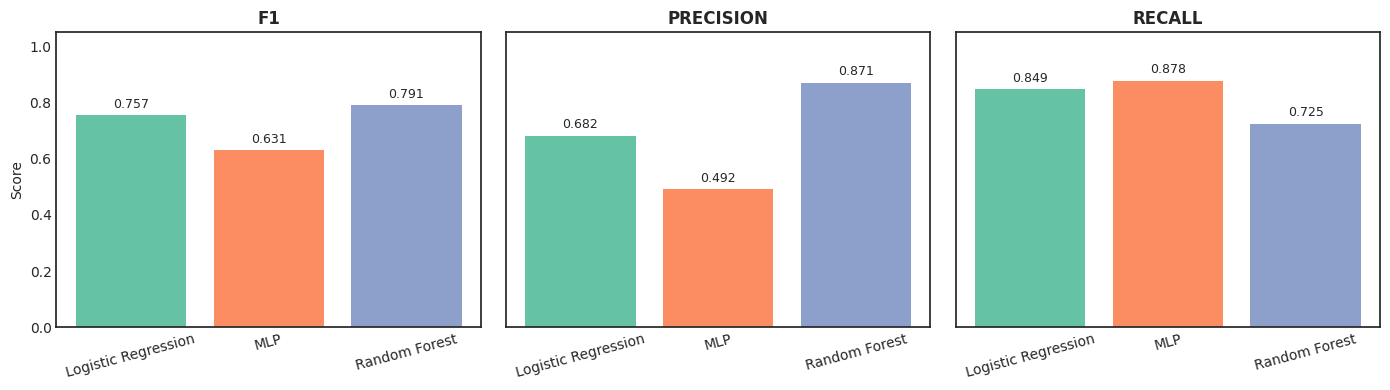

In [ ]:
fig, ax_f1 = plot_metric_grid(
    final_df,
    metrics=("f1", "precision", "recall"),
)

In [2]:
# precision recall plot
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    auc,
)

def plot_precision_recall(df, figsize=(6, 6), style="seaborn-v0_8-whitegrid",ax=None):

    model_colors = {
        "LR": "#378ADD",
        "RF": "#1D9E75",
        "MLP": "#D85A30",
    }

    with plt.style.context(style):
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig=None

        for model, sub in df.groupby("model"):

            precision, recall, _ = precision_recall_curve(
                sub["y_true"],
                sub["y_proba"],
            )

            ap = average_precision_score(
                sub["y_true"],
                sub["y_proba"],
            )

            pr_auc = auc(recall, precision)

            ax.plot(
                recall,
                precision,
                lw=2,
                color=model_colors.get(model, None),
                label=f"{model} (AP={ap:.3f}, AUC={pr_auc:.3f})",
            )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title("Precision–Recall Curves")
        ax.grid(alpha=0.3)
        ax.legend(loc="lower left")

        #plt.tight_layout()

    return fig, ax


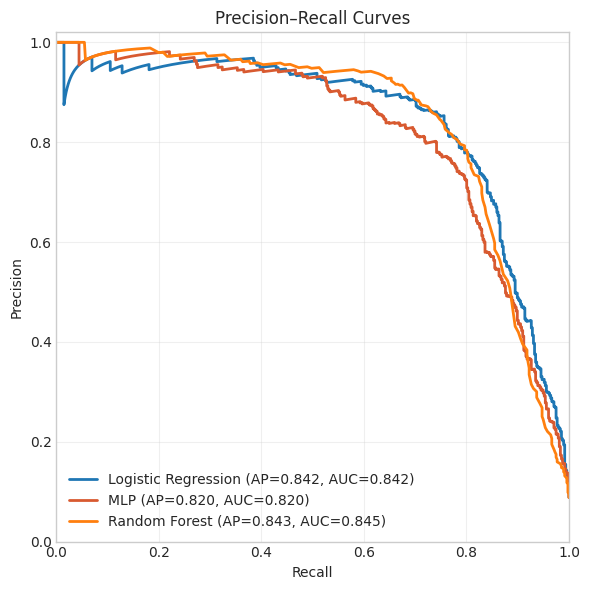

In [77]:
fig, ax = plot_precision_recall(final_df,ax=None)
plt.show()

In [55]:
# CONFUSION MATRIX CODE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix_grid(
    df,
    model_order=("LR", "RF", "MLP"),
    style="seaborn-v0_8-white",
    cmap="Blues",
    figsize=(10, 3.5),
):
    """
    Plot one confusion matrix per model.

    Each cell displays:
        count
        (row-normalized %)
    """

    model_order = [m for m in model_order if m in df["model"].unique()]
    n_cols = len(model_order)

    with plt.style.context(style):

        fig, axes = plt.subplots(
            1,
            n_cols,
            figsize=figsize,
            constrained_layout=True,
        )

        if n_cols == 1:
            axes = [axes]

        cms = {}
        cms_norm = {}

        for model in model_order:
            sub = df[df["model"] == model]

            cm = confusion_matrix(
                sub["y_true"],
                sub["y_pred"],
                labels=[0, 1],
            )

            cm_norm = confusion_matrix(
                sub["y_true"],
                sub["y_pred"],
                labels=[0, 1],
                normalize="true",
            )

            cms[model] = cm
            cms_norm[model] = cm_norm

        for ax, model in zip(axes, model_order):

            cm = cms[model]
            cm_norm = cms_norm[model]

            im = ax.imshow(
                cm_norm,
                cmap=cmap,
                vmin=0,
                vmax=1,
            )

            for i in range(2):
                for j in range(2):

                    pct = cm_norm[i, j]
                    count = cm[i, j]

                    color = "white" if pct > 0.5 else "black"

                    ax.text(
                        j,
                        i,
                        f"{count}\n({pct:.1%})",
                        ha="center",
                        va="center",
                        fontsize=11,
                        fontweight="bold",
                        color=color,
                    )

            ax.set_title(model, fontsize=12, fontweight="bold")
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Negative", "Positive"])
            ax.set_yticklabels(["Negative", "Positive"])
            ax.set_xlabel("Predicted")

        axes[0].set_ylabel("True", fontweight="bold")

        # cbar = fig.colorbar(
        #     im,
        #     ax=axes,
        #     shrink=0.8,
        #     pad=0.02,
        # )
        # cbar.set_label("Row-normalized proportion")

        fig.suptitle(
            "Confusion Matrices",
            fontsize=14,
            fontweight="bold",
        )

    return fig, axes

In [50]:
print(final_df["model"].unique())
print(final_df["model"].value_counts())

<ArrowStringArray>
['MLP', 'Random Forest', 'Logistic Regression']
Length: 3, dtype: str
model
MLP                    5395
Random Forest          5395
Logistic Regression    5395
Name: count, dtype: int64


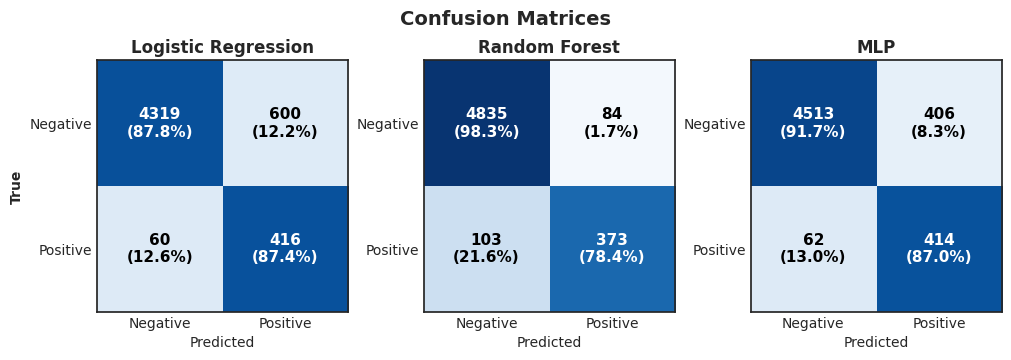

In [94]:
fig, axes = plot_confusion_matrix_grid(
    final_df,
    model_order=("Logistic Regression", "Random Forest", "MLP"),
)

plt.show()

In [4]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)
import seaborn as sns


def compute_metric_table(df, metric="f1"):
    metric_fns = {
        "f1": f1_score,
        "precision": precision_score,
        "recall": recall_score,
        "accuracy": accuracy_score,
    }

    rows = []

    for model, sub in df.groupby("model"):

        score = metric_fns[metric](
            sub["y_true"],
            sub["y_pred"],
            zero_division=0,
        )

        rows.append(
            {
                "model": model,
                metric: score,
            }
        )

    return pd.DataFrame(rows)


def plot_metric_bar(
    df,
    metric="f1",
    ax=None,
    palette=None,
):

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    metric_df = compute_metric_table(df, metric)

    if palette is None:
        palette = {
            "LR": "#378ADD",
            "RF": "#1D9E75",
            "MLP": "#D85A30",
            "Logistic Regression": "#378ADD",
            "Random Forest": "#1D9E75",
        }

    sns.barplot(
        data=metric_df,
        x="model",
        y=metric,
        hue="model",
        palette=palette,
        legend=False,
        ax=ax,
    )

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(metric.upper(), fontweight="bold")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            fontsize=9,
            padding=2,
        )

    sns.despine(ax=ax)

    return ax


## add here the precision-recall

In [3]:

def plot_precision_recall(
    df,
    ax=None,
    palette=None,
    title="Precision–Recall Curve",
    legend=True,
):

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if palette is None:
        palette = {
            "LR": "#378ADD",
            "RF": "#1D9E75",
            "MLP": "#D85A30",
            "Logistic Regression": "#378ADD",
            "Random Forest": "#1D9E75",
        }

    for model, sub in df.groupby("model"):

        precision, recall, _ = precision_recall_curve(
            sub["y_true"],
            sub["y_proba"],
        )

        ap = average_precision_score(
            sub["y_true"],
            sub["y_proba"],
        )

        ax.plot(
            recall,
            precision,
            lw=2.5,
            color=palette.get(model),
            label=f"{model} (AP={ap:.3f})",
        )

    ax.set(
        xlim=(0, 1),
        ylim=(0, 1.02),
        xlabel="Recall",
        ylabel="Precision",
        title=title,
    )

    ax.grid(alpha=0.3)

    if legend:
        ax.legend(loc="lower left", frameon=True)

    sns.despine(ax=ax)

    return ax

/tmp/ipykernel_791051/2200579416.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


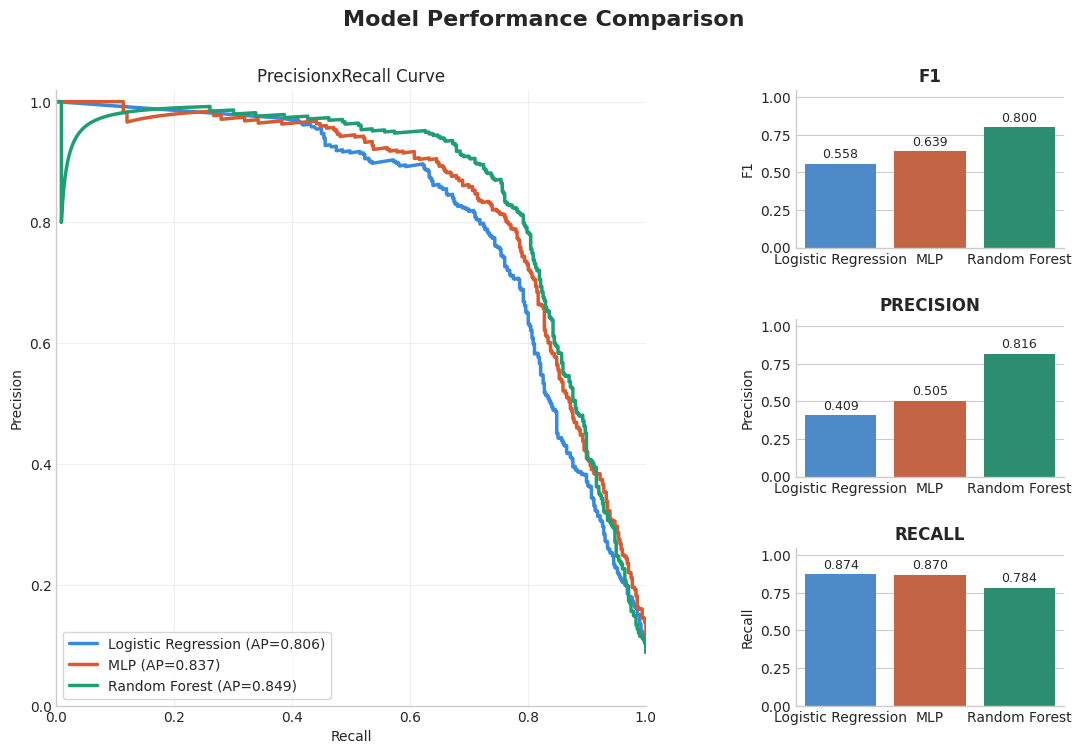

In [93]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

palette = {
            "LR": "#378ADD",
            "RF": "#1D9E75",
            "MLP": "#D85A30",
            "Logistic Regression": "#378ADD",
            "Random Forest": "#1D9E75",
        }


plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(13, 8))

gs = gridspec.GridSpec(
    3,
    2,
    width_ratios=[2.2, 1],
    wspace=0.35,
    hspace=0.45,
)

ax_pr = fig.add_subplot(gs[:, 0])

ax_f1 = fig.add_subplot(gs[0, 1])
ax_precision = fig.add_subplot(gs[1, 1], sharey=ax_f1)
ax_recall = fig.add_subplot(gs[2, 1], sharey=ax_f1)

plot_precision_recall(final_df, ax=ax_pr, palette=palette,
                             title="PrecisionxRecall Curve",
                             legend=True)


plot_metric_bar(final_df, "f1", ax=ax_f1)
plot_metric_bar(final_df, "precision", ax=ax_precision)
plot_metric_bar(final_df, "recall", ax=ax_recall)

fig.suptitle(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## Classification Deployed

In [46]:
def deploy_on_target(X_src, y_src, g_src, 
                     X_tgt, y_tgt,
                     name="NC->WP",
                     n_inner=5, seed=0, threshold=0.5):
    """
    Deployment-style evaluation:
      - Tune hyperparameters via grouped inner CV on source.
      - Refit best pipeline on ALL of source.
      - Predict once on target.

    Returns a long-form per-sample DataFrame with columns:
        experiment, model, sample_idx, y_true, y_pred, y_proba, threshold
    ready to be fed to plot_confusion_matrix_grid and plot_precision_recall.
    """
    n_groups = len(set(g_src))
    n_inner  = min(n_inner, n_groups)
    print(f"\n[{name}] src={len(y_src)} ({y_src.sum()} pos), "
          f"tgt={len(y_tgt)} ({y_tgt.sum()} pos), "
          f"inner={n_inner}, threshold={threshold}")

    sk_models = {
        "LR": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  LogisticRegression(max_iter=2000,
                                                     class_weight="balanced"))]),
               {"clf__C": [0.1, 1, 10]}),
        "RF": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  RandomForestClassifier(class_weight="balanced",
                                                          random_state=seed,
                                                          n_jobs=-1))]),
               {"clf__n_estimators": [300,500, 900],
                "clf__max_depth":    [5, 10, 20],
                "clf__min_samples_leaf": [1, 3]}),
    }

    per_sample = []

    # ---- LR / RF via GridSearchCV ----
    for model_name, (pipe, grid) in sk_models.items():
        inner_cv = StratifiedGroupKFold(n_splits=n_inner, shuffle=True,
                                        random_state=seed)
        gs = GridSearchCV(pipe, grid,
                          cv=inner_cv.split(X_src, y_src, g_src),
                          scoring="average_precision",
                          n_jobs=-1, refit=True)
        gs.fit(X_src, y_src)
        print(f"  {model_name} best: {gs.best_params_}  CV AP={gs.best_score_:.3f}")

        proba = gs.predict_proba(X_tgt)[:, 1]
        pred  = (proba >= threshold).astype(int)

        per_sample.append(pd.DataFrame({
            "experiment": name,
            "model":      model_name,
            "sample_idx": np.arange(len(y_tgt)),
            "y_true":     y_tgt.astype(int),
            "y_pred":     pred.astype(int),
            "y_proba":    proba.astype(float),
            "threshold":  float(threshold),
        }))

    # ---- MLP ----
    norm = Normalizer(norm="l2")
    X_src_n = norm.fit_transform(X_src)
    X_tgt_n = norm.transform(X_tgt)
    proba_mlp, _, _, best_vl = _mlp_train_and_predict(
        X_src_n, y_src, X_tgt_n,
        input_dim=X_src_n.shape[1],
        seed=seed,
        tune_threshold=False,
    )
    pred_mlp = (proba_mlp >= threshold).astype(int)
    print(f"  MLP best_val_loss={best_vl:.4f}")

    per_sample.append(pd.DataFrame({
        "experiment": name,
        "model":      "MLP",
        "sample_idx": np.arange(len(y_tgt)),
        "y_true":     y_tgt.astype(int),
        "y_pred":     pred_mlp.astype(int),
        "y_proba":    proba_mlp.astype(float),
        "threshold":  float(threshold),
    }))

    return pd.concat(per_sample, ignore_index=True)

# Hyperparameters tuning

In [44]:
label_lookup = {
    s.id: s.get_field("type_label")
    for s in dataset.select_fields("type_label")
}

group_lookup = {
    s.id: s.get_field("mission_name")   # <- your field name
    for s in dataset.select_fields("mission_name")
}

In [45]:
def _build_X_y(ids, sample_id_to_row):
    rows, labels, groups = [], [], []
    missing_embedding, missing_label = [], []

    for sid in ids:
        row_idx = sample_id_to_row.get(sid)
        if row_idx is None:
            missing_embedding.append(sid)
            continue

        lab = label_lookup.get(sid)
        if lab == "positive":
            y_val = 1
        elif lab == "negative":
            y_val = 0
        else:
            missing_label.append(sid)
            continue

        rows.append(row_idx)
        labels.append(y_val)
        groups.append(group_lookup.get(sid))

    X = embedding_retrieved[rows]
    y = np.array(labels)
    g = np.array(groups)
    return X, y, g, missing_embedding, missing_label

In [90]:
def create_train_test_classification(train_set_id, test_set_id, sample_id_to_row):
    X_train, y_train, g_train, miss_emb_tr, miss_lab_tr = _build_X_y(train_set_id, sample_id_to_row)
    X_test,  y_test,  _,       miss_emb_te, miss_lab_te = _build_X_y(test_set_id,  sample_id_to_row)

    print(f"Train: {X_train.shape[0]} rows, {len(set(g_train))} flight missions")
    print(f"Test:  {X_test.shape[0]} rows")

    # NOTE: don't normalize here anymore — put it inside the Pipeline (see below)
    return X_train, y_train, g_train, X_test, y_test

In [91]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, y_train, g_train, X_test, y_test = create_train_test_classification(
    train_set_id=train_ids,
    test_set_id=test_ids,
    sample_id_to_row=sample_id_to_row,
)

n_splits = min(5, len(set(g_train)))   # can't have more folds than groups
cv = GroupKFold(n_splits=n_splits)

# ---- Logistic Regression ----
lr_pipe = Pipeline([
    ("norm", Normalizer(norm="l2")),
    ("clf",  LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}

gs_lr = GridSearchCV(
    lr_pipe, lr_grid,
    cv=cv.split(X_train, y_train, groups=g_train),
    scoring="average_precision",   # good default for imbalanced binary
    n_jobs=-1,
    refit=True,
)
gs_lr.fit(X_train, y_train)
print("LR best:", gs_lr.best_params_, gs_lr.best_score_)

# ---- Random Forest ----
rf_pipe = Pipeline([
    ("norm", Normalizer(norm="l2")),
    ("clf",  RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1)),
])
rf_grid = {
    "clf__n_estimators": [300, 600],
    "clf__max_depth":    [None, 10, 20],
    "clf__min_samples_leaf": [1, 3, 5],
}
gs_rf = GridSearchCV(
    rf_pipe, rf_grid,
    cv=cv.split(X_train, y_train, groups=g_train),
    scoring="average_precision",
    n_jobs=-1,
)
gs_rf.fit(X_train, y_train)
print("RF best:", gs_rf.best_params_, gs_rf.best_score_)

Train: 5728 rows, 25 flight missions
Test:  5395 rows
LR best: {'clf__C': 100} 0.9189742731593507
RF best: {'clf__max_depth': 20, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 600} 0.8579689310827963


# Cross Fold Validation

In [10]:
# MLP
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


def find_best_threshold(y_true, y_proba, metric: str = "f1", n_steps: int = 199):
    """
    Sweeps decision thresholds in (0, 1) and returns the one that maximises
    the given metric on the provided (y_true, y_proba) pair.

    IMPORTANT: call this on a VALIDATION split, never on the test set --
    tuning the threshold against test labels would leak test information
    into model selection and bias the reported test metrics optimistically.

    Parameters
    ----------
    y_true   : array-like (n,) int {0,1}
    y_proba  : array-like (n,) float -- predicted P(class=1)
    metric   : "f1" | "precision" | "recall" | "accuracy"
    n_steps  : int -- number of threshold candidates to try, evenly spaced
                in (0, 1) (default 199 -> step size 0.005)

    Returns
    -------
    best_threshold : float
    best_score     : float
    """
    metric_fns = {
        "f1":        f1_score,
        "precision": precision_score,
        "recall":    recall_score,
        "accuracy":  accuracy_score,
    }
    if metric not in metric_fns:
        raise ValueError(f"metric must be one of {list(metric_fns)}, got '{metric}'")
    score_fn = metric_fns[metric]

    y_true  = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    thresholds = np.linspace(0.005, 0.995, n_steps)
    best_threshold, best_score = 0.5, -1.0

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        score = score_fn(y_true, y_pred_t, zero_division=0) if metric != "accuracy" \
                else score_fn(y_true, y_pred_t)
        if score > best_score:
            best_score = score
            best_threshold = t

    return float(best_threshold), float(best_score)

class DugongMLP(nn.Module):
    """
    Shallow expand-then-contract MLP:
        1024 -> 1536 -> 768 -> 256 -> 1 (logit)

    ReLU activations + dropout on every hidden layer (regularisation against
    overfitting -- with only a few thousand training rows and a 1024-dim
    input, this network has enough capacity to memorise the training set
    without it). Outputs a single raw logit (no sigmoid applied internally)
    -- use BCEWithLogitsLoss for training and torch.sigmoid(logits) to get
    probabilities at inference time.
    """
    def __init__(self, input_dim: int = 1024, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1536),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1536, 768),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),   # raw logit, no activation
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
    
def _mlp_train_and_predict(
    X_tr_full, y_tr_full, X_te,
    input_dim,
    val_size=0.15,
    batch_size=64,
    max_epochs=200,
    patience=15,
    lr=1e-3,
    weight_decay=1e-3,
    tune_threshold=True,
    threshold_metric="f1",
    device=None,
    seed=0,
):
    """
    Train a DugongMLP on (X_tr_full, y_tr_full) with an internal stratified
    val split for early stopping + threshold tuning, then return probas,
    predictions, and the tuned threshold for X_te.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(seed)

    # internal train/val split (stratified)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full, y_tr_full,
        test_size=val_size, stratify=y_tr_full,
        random_state=seed, shuffle=True,
    )

    # class-weighted loss
    n_pos = max(int(y_tr.sum()), 1)
    n_neg = max(int(len(y_tr) - y_tr.sum()), 1)
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # tensors
    def _to_t(X, y=None):
        X_t = torch.tensor(np.asarray(X), dtype=torch.float32)
        if y is None: return X_t
        return X_t, torch.tensor(np.asarray(y), dtype=torch.float32)

    X_tr_t,  y_tr_t  = _to_t(X_tr, y_tr)
    X_val_t, y_val_t = _to_t(X_val, y_val)
    X_te_t           = _to_t(X_te)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                              batch_size=batch_size, shuffle=False)

    model = DugongMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss, best_state, no_improve = float("inf"), None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        vl_sum, vl_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl_sum += criterion(model(xb), yb).item() * xb.size(0)
                vl_n   += xb.size(0)
        val_loss = vl_sum / vl_n

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    # threshold tuning on val
    with torch.no_grad():
        val_proba = torch.sigmoid(model(X_val_t.to(device))).cpu().numpy().ravel()
    if tune_threshold:
        thr, _ = find_best_threshold(y_val, val_proba, metric=threshold_metric)
    else:
        thr = 0.5

    # inference on test
    with torch.no_grad():
        te_proba = torch.sigmoid(model(X_te_t.to(device))).cpu().numpy().ravel()
    te_pred = (te_proba >= thr).astype(int)

    return te_proba, te_pred, thr, best_val_loss

In [23]:
# IN DOMAIN SET OF FUNCTION
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.metrics import precision_recall_curve

def threshold_at_recall(y, proba, target_recall=0.90):
    prec, rec, thr = precision_recall_curve(y, proba)
    # rec and prec are aligned; thr has one fewer element
    # pick the largest threshold that still achieves target_recall
    mask = rec[:-1] >= target_recall   # drop last elem to match thr
    if not mask.any():
        return 0.0                     # no threshold reaches target; predict all pos
    return thr[mask].max()



def _row(name, model_name, fold_i, y_te, pred, proba, extra=None):
    row = {
        "experiment": name, "model": model_name, "fold": fold_i,
        "n_test": len(y_te), "pos_rate_test": float(y_te.mean()),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall":    recall_score(y_te, pred, zero_division=0),
        "f1":        f1_score(y_te, pred, zero_division=0),
        "pr_auc":    average_precision_score(y_te, proba),
        "roc_auc":   roc_auc_score(y_te, proba),
        "y_true":    np.asarray(y_te).astype(int).tolist(),
        "y_proba":   np.asarray(proba).astype(float).tolist(),
        "y_pred":    np.asarray(pred).astype(int).tolist(),
    }
    if extra:
        if extra.pop("store_preds", True) is False:
            row.pop("y_true"); row.pop("y_proba"); row.pop("y_pred")
    row.update(extra)
    return row

def evaluate_in_domain(X, y, groups, name,
                       n_outer=5, n_inner=3,
                       seed=0, threshold=0.5):
    n_groups = len(set(groups))
    n_outer  = min(n_outer, n_groups)
    n_inner  = min(n_inner, n_groups - 1)
    print(f"\n[{name}] {len(y)} samples, {y.sum()} positives, "
          f"{n_groups} flights → {n_outer} outer / {n_inner} inner folds, "
          f"threshold={threshold}")

    outer_cv = StratifiedGroupKFold(n_splits=n_outer, shuffle=True, random_state=seed)

    sk_models = {
        "LR": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  LogisticRegression(max_iter=2000,
                                                     class_weight="balanced"))]),
               {"clf__C": [0.01, 0.1, 1, 10, 100]}),
        "RF": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  RandomForestClassifier(class_weight="balanced",
                                                          random_state=seed,
                                                          n_jobs=-1))]),
               {"clf__n_estimators": [300, 600],
                "clf__max_depth":    [5, 10, 20],
                "clf__min_samples_leaf": [1, 3]}),
    }

    rows = []
    for fold_i, (tr, te) in enumerate(outer_cv.split(X, y, groups)):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        g_tr        = groups[tr]

        # --- LR / RF ---
        for model_name, (pipe, grid) in sk_models.items():
            inner_cv = StratifiedGroupKFold(n_splits=n_inner, shuffle=True,
                                            random_state=seed)
            gs = GridSearchCV(pipe, grid,
                              cv=inner_cv.split(X_tr, y_tr, g_tr),
                              scoring="average_precision",
                              n_jobs=-1, refit=True)
            gs.fit(X_tr, y_tr)

            proba = gs.predict_proba(X_te)[:, 1]
            pred  = (proba >= threshold).astype(int)

            rows.append(_row(name, model_name, fold_i, y_te, pred, proba,
                             extra={"best_params": str(gs.best_params_),
                                    "threshold": float(threshold)}))

        # --- MLP (fixed threshold, no internal F1 tuning, for comparability) ---
        norm = Normalizer(norm="l2")
        X_tr_n = norm.fit_transform(X_tr)
        X_te_n = norm.transform(X_te)

        proba, _, _, best_vl = _mlp_train_and_predict(
            X_tr_n, y_tr, X_te_n,
            input_dim=X_tr_n.shape[1],
            seed=seed,
            tune_threshold=False,
        )
        pred = (proba >= threshold).astype(int)

        rows.append(_row(name, "MLP", fold_i, y_te, pred, proba,
                         extra={"best_params": f"best_val_loss={best_vl:.4f}",
                                "threshold": float(threshold)}))

    return pd.DataFrame(rows)

In [ ]:
## CROSS DOMAIN
def evaluate_cross_domain(X_src, y_src, g_src,
                          X_tgt, y_tgt, flights_tgt,
                          name,
                          n_inner=5,
                          n_boot=1000,
                          threshold=0.5,
                          seed=0):
    """
    Train on source (with grouped inner CV for hyperparameter tuning),
    evaluate once on target, and compute uncertainty via a FLIGHT-LEVEL
    cluster bootstrap on target.

    Parameters
    ----------
    flights_tgt : array-like of length len(y_tgt)
        Flight mission id for each target sample. Used to resample entire
        flights (with replacement) in the bootstrap, respecting within-flight
        correlation.
    threshold : float, default 0.5
        Decision threshold for LR / RF. MLP uses the same value; its internal
        F1-tuning is bypassed for comparability across models.
    """
    n_groups = len(set(g_src))
    n_inner  = min(n_inner, n_groups)
    flights_tgt = np.asarray(flights_tgt)
    unique_flights = np.array(sorted(set(flights_tgt)))
    print(f"\n[{name}] src={len(y_src)} ({y_src.sum()} pos), "
          f"tgt={len(y_tgt)} ({y_tgt.sum()} pos), "
          f"inner={n_inner}, target_flights={len(unique_flights)}, "
          f"threshold={threshold}")

    sk_models = {
        "LR": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  LogisticRegression(max_iter=2000,
                                                     class_weight="balanced"))]),
               {"clf__C": [0.1, 1, 10]}),
        "RF": (Pipeline([("norm", Normalizer(norm="l2")),
                         ("clf",  RandomForestClassifier(class_weight="balanced",
                                                          random_state=seed,
                                                          n_jobs=-1))]),
               {"clf__n_estimators": [250, 700],
                "clf__max_depth":    [2, 5, 10],
                "clf__min_samples_leaf": [2, 5]}),
    }

    rows = []
    rng = np.random.default_rng(seed)
    all_preds = {}

    # --- LR / RF ---
    for model_name, (pipe, grid) in sk_models.items():
        inner_cv = StratifiedGroupKFold(n_splits=n_inner, 
                                        shuffle=True,
                                        random_state=seed)
        gs = GridSearchCV(pipe, grid,
                          cv=inner_cv.split(X_src, y_src, g_src),
                          scoring="average_precision",
                          n_jobs=-1, refit=True)
        gs.fit(X_src, y_src)

        proba = gs.predict_proba(X_tgt)[:, 1]
        pred  = (proba >= threshold).astype(int)

        all_preds[model_name] = (proba, pred,
                                 {"best_params": str(gs.best_params_),
                                  "threshold": float(threshold)})

    # --- MLP (use fixed threshold for comparability) ---
    norm = Normalizer(norm="l2")
    X_src_n = norm.fit_transform(X_src)
    X_tgt_n = norm.transform(X_tgt)
    proba_mlp, _, thr_internal, best_vl = _mlp_train_and_predict(
        X_src_n, y_src, X_tgt_n,
        input_dim=X_src_n.shape[1],
        seed=seed,
        tune_threshold=False,   # ignore the internal F1-tuned threshold
    )
    pred_mlp = (proba_mlp >= threshold).astype(int)
    all_preds["MLP"] = (proba_mlp, pred_mlp,
                        {"best_params": f"best_val_loss={best_vl:.4f}",
                         "threshold": float(threshold)})

    # --- precompute per-flight indices for cluster bootstrap ---
    flight_to_idx = {f: np.where(flights_tgt == f)[0] for f in unique_flights}
    n_flights = len(unique_flights)

    # --- point + cluster bootstrap rows ---
    for model_name, (proba, pred, extra) in all_preds.items():
        rows.append(_row(name, model_name, "point", y_tgt, pred, proba, extra=extra))

        for b in range(n_boot):
            sampled = rng.choice(unique_flights, size=n_flights, replace=True)
            idx = np.concatenate([flight_to_idx[f] for f in sampled])

            y_b = y_tgt[idx]
            if y_b.sum() == 0 or y_b.sum() == len(y_b):
                continue

            rows.append(_row(name, model_name, f"boot_{b}",
                             y_b, pred[idx], proba[idx],
                             extra={**extra, "store_preds": False}))

    return pd.DataFrame(rows)

### draft - jump

In [63]:
df_nc = evaluate_in_domain(X_nc, y_nc, g_nc, "NC->NC", target_recall=0.70)
print(df_nc.groupby("model")[["threshold","recall","precision"]].agg(["mean","std"]))


[NC->NC] 5728 samples, 2070 positives, 25 flights → 5 outer / 3 inner folds, target_recall=0.7
      threshold              recall           precision          
           mean       std      mean       std      mean       std
model                                                            
LR     0.855437  0.054858  0.617302  0.062482  0.961941  0.021705
MLP    0.532000  0.185896  0.808817  0.064142  0.837157  0.023298
RF     0.791360  0.036804  0.258302  0.081008  1.000000  0.000000


In [65]:
df_nc = evaluate_in_domain(X_nc, y_nc, g_nc, "NC->NC", target_recall=0.50)
print(df_nc.groupby("model")[["threshold","recall","precision"]].agg(["mean","std"]))


[NC->NC] 5728 samples, 2070 positives, 25 flights → 5 outer / 3 inner folds, target_recall=0.5
      threshold              recall           precision          
           mean       std      mean       std      mean       std
model                                                            
LR     0.959417  0.020973  0.485639  0.059488  0.992797  0.007958
MLP    0.532000  0.185896  0.808817  0.064142  0.837157  0.023298
RF     0.856792  0.025729  0.201685  0.103575  1.000000  0.000000


In [59]:
df_nc.columns

Index(['experiment', 'model', 'fold', 'n_test', 'pos_rate_test', 'precision',
       'recall', 'f1', 'pr_auc', 'roc_auc', 'y_true', 'y_proba', 'y_pred',
       'best_params', 'threshold', 'target_recall'],
      dtype='str')

In [60]:
print(df_nc.groupby("model")[["threshold","recall","precision","f1"]].agg(["mean","std"]))

      threshold              recall           precision                  f1  \
           mean       std      mean       std      mean       std      mean   
model                                                                         
LR     0.589981  0.078684  0.774329  0.056774  0.857106  0.033208  0.812876   
MLP    0.532000  0.185896  0.808817  0.064142  0.837157  0.023298  0.821962   
RF     0.694028  0.054310  0.334583  0.057479  0.995407  0.006640  0.498680   

                 
            std  
model            
LR     0.039209  
MLP    0.039931  
RF     0.062469  


In [ ]:
df_nc2wp = evaluate_cross_domain(X_nc, y_nc, g_nc, X_wp, y_wp,
                                  "NC->WP", target_recall=0.70)
df_wp2nc = evaluate_cross_domain(X_wp, y_wp, g_wp_cv, X_nc, y_nc,
                                  "WP->NC", target_recall=0.70)

# --- sanity check: point rows only (no bootstrap noise) ---
sanity = pd.concat([df_nc2wp, df_wp2nc])
sanity = sanity[sanity["fold"].astype(str) == "point"]

print(sanity[["experiment","model","threshold","recall","precision","f1","roc_auc"]]
      .round(3).to_string(index=False))

In [25]:
df_verify.groupby("region")["label"].agg(["count", "sum", "mean"])

,count,sum,mean
region,,,
NC,5728,2070,0.361383
WP,5395,476,0.088230


### pipeline start

In [15]:
# load embeddings 
from sklearn.preprocessing import normalize

data_embedding_tile        = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz")

sample_ids = data_embedding_tile['sample_ids']

embedding_retrieved = data_embedding_tile['embeddings']

In [19]:
mission_lookup = {
    s.id: s.get_field("mission")
    for s in dataset.select_fields("mission")
}

label_lookup = {
    s.id: s.get_field("type_label")
    for s in dataset.select_fields("type_label")
}

#  each sample_id (coming from the npz) maps to row index in the embedding array 
sample_id_to_row = {sid: i for i, sid in enumerate(sample_ids)}


In [50]:
# Build X and Y for training classification
def _build_X_y(ids, sample_id_to_row):
    rows, labels, missions = [], [], []
    missing_embedding, missing_label = [], []

    for sid in ids:
        row_idx = sample_id_to_row.get(sid)
        if row_idx is None:
            missing_embedding.append(sid); continue

        lab = label_lookup.get(sid)
        if lab == "positive":   y_val = 1
        elif lab == "negative": y_val = 0
        else:
            missing_label.append(sid); continue

        rows.append(row_idx)
        labels.append(y_val)
        missions.append(mission_lookup.get(sid))

    X = embedding_retrieved[rows]
    y = np.array(labels)
    g = np.array(missions)   # <-- this is your groups array
    return X, y, g

In [21]:
nc_ids = dataset.match(ViewField("region") == "NC").values("id")
wp_ids = dataset.match(ViewField("region") == "WP").values("id")

X_nc, y_nc, g_nc = _build_X_y(nc_ids, sample_id_to_row)
X_wp, y_wp, g_wp = _build_X_y(wp_ids, sample_id_to_row)

In [22]:
# count positives per flight in WP
from collections import Counter
pos_per_flight = Counter()
count_per_flight = Counter()
for m, y in zip(g_wp, y_wp):
    pos_per_flight[m] += y
    count_per_flight[m] += 1

tiny_flights = {m for m in pos_per_flight if pos_per_flight[m] < 10}
print("Merging into 'small_flights':", tiny_flights)

g_wp_cv = np.array([
    "small_flights" if m in tiny_flights else m
    for m in g_wp
])

Merging into 'small_flights': {np.str_('friwen_19'), np.str_('mantasandy_5'), np.str_('um_3'), np.str_('gam_10')}


In [25]:
# EVALUATE IN DOMAIN
import pandas as pd
df_nc = evaluate_in_domain(X_nc, y_nc, g_nc, "NC->NC", n_outer=5, n_inner=3)
df_wp = evaluate_in_domain(X_wp, y_wp, g_wp_cv, "WP->WP", n_outer=4, n_inner=2)

results = pd.concat([df_nc, df_wp], ignore_index=True)



[NC->NC] 5728 samples, 2070 positives, 25 flights → 5 outer / 3 inner folds, threshold=0.5



[WP->WP] 5395 samples, 476 positives, 16 flights → 4 outer / 2 inner folds, threshold=0.5


In [53]:
results.to_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/in_domain_results.parquet")   

In [27]:
df_nc2wp = evaluate_cross_domain(
    X_nc, y_nc, g_nc,
    X_wp, y_wp, g_wp,       # <-- flights_tgt
    "NC->WP",
)
df_wp2nc = evaluate_cross_domain(
    X_wp, y_wp, g_wp_cv,     # inner CV pooling on WP as source
    X_nc, y_nc, g_nc,        # flights_tgt on NC
    "WP->NC",
)

all_results = pd.concat([df_nc, df_wp, df_nc2wp, df_wp2nc], ignore_index=True)
#all_results.to_parquet("all_cv_results.parquet")


[NC->WP] src=5728 (2070 pos), tgt=5395 (476 pos), inner=5, target_flights=19, threshold=0.5

[WP->NC] src=5395 (476 pos), tgt=5728 (2070 pos), inner=5, target_flights=25, threshold=0.5


In [28]:
all_results["fold"] = all_results["fold"].astype(str)
all_results.to_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/all_results_intra_cross_domain_v3.parquet")

In [2]:
import pandas as pd
import numpy as np 
all_results= pd.read_parquet('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/all_results_intra_cross_domain_v3.parquet')

In [21]:
all_results.loc[all_results['experiment']=="WP->NC"]

,experiment,model,fold,n_test,pos_rate_test,precision,recall,f1,pr_auc,roc_auc,y_true,y_proba,y_pred,best_params,threshold
3030,WP->NC,LR,point,5728,0.361383,0.883495,0.527536,0.660617,0.830966,0.866858,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.9930844519084769, 0.848727722803203, 0.8731...","[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, ...",{'clf__C': 10},0.5
3031,WP->NC,LR,boot_0,4728,0.361041,0.885932,0.545987,0.675607,0.843836,0.883961,None,None,None,{'clf__C': 10},0.5
3032,WP->NC,LR,boot_1,5512,0.373911,0.864668,0.517710,0.647648,0.832260,0.868497,None,None,None,{'clf__C': 10},0.5
3033,WP->NC,LR,boot_2,4880,0.354508,0.887801,0.576301,0.698913,0.849872,0.885805,None,None,None,{'clf__C': 10},0.5
3034,WP->NC,LR,boot_3,6224,0.375803,0.901132,0.510475,0.651747,0.825429,0.847529,None,None,None,{'clf__C': 10},0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6028,WP->NC,MLP,boot_995,6688,0.356459,0.805637,0.575503,0.671397,0.800091,0.834394,None,None,None,best_val_loss=0.1785,0.5
6029,WP->NC,MLP,boot_996,7288,0.358809,0.845588,0.615679,0.712547,0.840696,0.875919,None,None,None,best_val_loss=0.1785,0.5
6030,WP->NC,MLP,boot_997,5000,0.367400,0.846978,0.602613,0.704198,0.836574,0.867648,None,None,None,best_val_loss=0.1785,0.5
6031,WP->NC,MLP,boot_998,7592,0.354452,0.856000,0.596433,0.703022,0.840411,0.876115,None,None,None,best_val_loss=0.1785,0.5


In [3]:
all_results.columns

Index(['experiment', 'model', 'fold', 'n_test', 'pos_rate_test', 'precision',
       'recall', 'f1', 'pr_auc', 'roc_auc', 'y_true', 'y_proba', 'y_pred',
       'best_params', 'threshold'],
      dtype='str')

In [72]:
all_results.shape

(6033, 16)

In [14]:
all_results[[ 'experiment','model','precision','recall', 'f1', 'pr_auc', 'roc_auc']].groupby(['experiment','model']).agg(['mean','std']).round(2)

precision       recall          f1       pr_auc        \
                      mean   std   mean   std  mean   std   mean   std   
experiment model                                                         
NC->NC     LR         0.82  0.03   0.80  0.05  0.81  0.03   0.92  0.02   
           MLP        0.83  0.06   0.81  0.04  0.82  0.04   0.92  0.03   
           RF         0.96  0.03   0.49  0.07  0.65  0.06   0.87  0.03   
NC->WP     LR         0.66  0.05   0.87  0.04  0.75  0.03   0.85  0.03   
           MLP        0.34  0.03   0.94  0.02  0.50  0.04   0.85  0.04   
           RF         0.84  0.03   0.77  0.06  0.80  0.03   0.86  0.03   
WP->NC     LR         0.88  0.03   0.53  0.04  0.66  0.03   0.83  0.02   
           MLP        0.83  0.03   0.62  0.03  0.71  0.02   0.84  0.02   
           RF         0.99  0.01   0.16  0.04  0.27  0.06   0.76  0.03   
WP->WP     LR         0.83  0.07   0.85  0.08  0.83  0.03   0.90  0.04   
           MLP        0.62  0.13   0.90  0.08  0.72  0.08   0.90  0.04   
           RF         0.96  0.03   0.66  0.08  0.78  0.06   0.87  0.07   

                 roc_auc        
                    mean   std  
experiment model                
NC->NC     LR       0.94  0.02  
           MLP      0.94  0.02  
           RF       0.90  0.03  
NC->WP     LR       0.97  0.01  
           MLP      0.96  0.01  
           RF       0.96  0.02  
WP->NC     LR       0.87  0.02  
           MLP      0.87  0.02  
           RF       0.80  0.02  
WP->WP     LR       0.97  0.02  
           MLP      0.98  0.01  
           RF       0.96  0.03

## Classification Deployed

In [48]:
dataset.count_values("subregion")

{'MANTASANDY': 105, 'UM': 3940, 'NC': 5728, 'FRIWEN': 945, 'GAM': 405}

In [ ]:
dataset.match(
    ViewField("regi")
)

In [51]:
nc_ids = dataset.match(ViewField("region") == "NC").values("id")
um_ids = dataset.match(ViewField("subregion") == "UM").values("id")

X_nc, y_nc, g_nc = _build_X_y(nc_ids, sample_id_to_row)
X_um, y_um, g_um = _build_X_y(wp_ids, sample_id_to_row)

In [57]:
preds_nc2wp.to_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/deploy_nc2wp.parquet")

In [1]:
import pandas as pd 
preds_nc2wp = pd.read_parquet('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/deploy_nc2wp.parquet')

In [ ]:
preds_nc2wp = deploy_on_target(X_nc, y_nc, g_nc, X_um, y_um, name="NC->WP")
#preds_wp2nc = deploy_on_target(X_wp, y_wp, g_wp_cv, X_nc, y_nc, name="WP->NC")

# save
#preds_nc2wp.to_parquet("deploy_nc2wp.parquet")

# plot
#fig, _ = plot_confusion_matrix_grid(preds_nc2wp)
#fig, _ = plot_precision_recall(preds_nc2wp)


[NC->WP] src=5728 (2070 pos), tgt=5395 (476 pos), inner=5, threshold=0.5


  LR best: {'clf__C': 10}  CV AP=0.919
  RF best: {'clf__max_depth': 10, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}  CV AP=0.868
  MLP best_val_loss=0.1604


In [9]:
df["model"].unique().tolist()

['LR', 'RF', 'MLP']

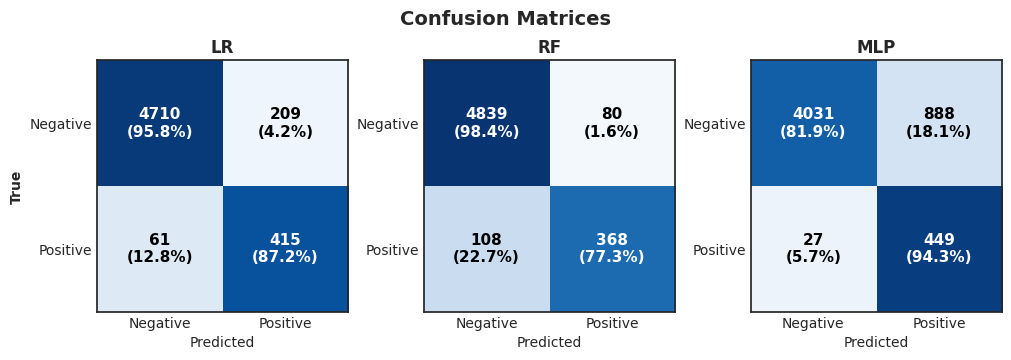

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ---- Corrected variable assignments (no trailing commas) ----
df = preds_nc2wp.copy()
model_order = ("LR", "RF", "MLP")          # removed comma
style = "seaborn-v0_8-white"               # removed comma
cmap = "Blues"                             # removed comma
figsize = (10, 3.5)                        # removed comma

# Ensure model_order matches the actual models present
model_order = df["model"].unique().tolist()  # keep as list
n_cols = len(model_order)

with plt.style.context(style):
    # Create subplots dynamically based on number of models
    fig, axes = plt.subplots(
        1, n_cols,
        figsize=figsize,
        constrained_layout=True,
    )
    # If only one model, axes is not a list
    if n_cols == 1:
        axes = [axes]

    cms = {}
    cms_norm = {}

    for model in model_order:
        sub = df[df["model"] == model]
        cm = confusion_matrix(
            sub["y_true"],
            sub["y_pred"],
            labels=[0, 1],
        )
        cm_norm = confusion_matrix(
            sub["y_true"],
            sub["y_pred"],
            labels=[0, 1],
            normalize="true",
        )
        cms[model] = cm
        cms_norm[model] = cm_norm

    for ax, model in zip(axes, model_order):
        cm = cms[model]
        cm_norm = cms_norm[model]

        im = ax.imshow(
            cm_norm,
            cmap=cmap,
            vmin=0,
            vmax=1,
        )

        for i in range(2):
            for j in range(2):
                pct = cm_norm[i, j]
                count = cm[i, j]
                color = "white" if pct > 0.5 else "black"
                ax.text(
                    j, i,
                    f"{count}\n({pct:.1%})",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color=color,
                )

        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Negative", "Positive"])
        ax.set_yticklabels(["Negative", "Positive"])
        ax.set_xlabel("Predicted")

    axes[0].set_ylabel("True", fontweight="bold")

    # Optional colorbar (uncomment if needed)
    # cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
    # cbar.set_label("Row-normalized proportion")

    fig.suptitle(
        "Confusion Matrices",
        fontsize=14,
        fontweight="bold",
    )

plt.show()

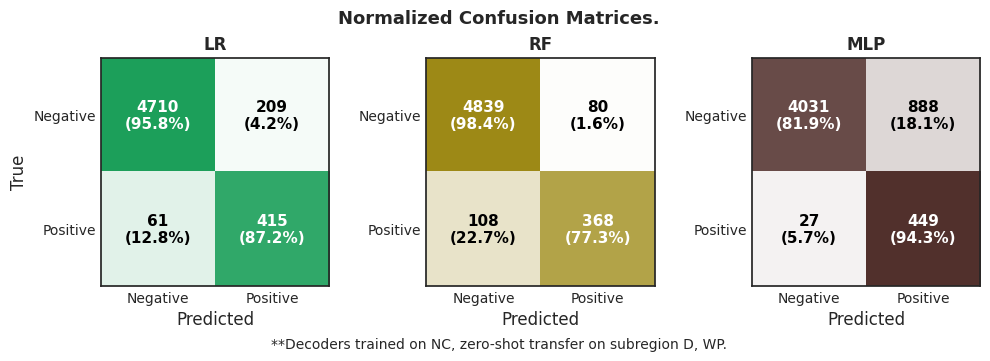

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# ---- Data ----
df = preds_nc2wp.copy()
model_order = df["model"].unique().tolist()   # ['LR', 'RF', 'MLP']
n_cols = len(model_order)

# ---- Decoder colours (same as boxplots) ----
decoder_colours = {
    "LR": "#139C54",
    "RF": "#9C8813",
    "MLP": "#472420"
}

# Create custom colormaps: white → decoder colour
def make_cmap(color):
    return LinearSegmentedColormap.from_list('custom_cmap', ['white', color])

model_cmap = {model: make_cmap(decoder_colours[model]) for model in model_order}

# ---- Plot ----
style = "seaborn-v0_8-white"          # no trailing comma
figsize = (10, 3.5)                   # no trailing comma

with plt.style.context(style):
    fig, axes = plt.subplots(1, n_cols, figsize=figsize, constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    cms = {}
    cms_norm = {}
    for model in model_order:
        sub = df[df["model"] == model]
        cm = confusion_matrix(sub["y_true"], sub["y_pred"], labels=[0, 1])
        cm_norm = confusion_matrix(sub["y_true"], sub["y_pred"], labels=[0, 1], normalize="true")
        cms[model] = cm
        cms_norm[model] = cm_norm

    for ax, model in zip(axes, model_order):
        cm = cms[model]
        cm_norm = cms_norm[model]
        cmap = model_cmap[model]

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

        for i in range(2):
            for j in range(2):
                pct = cm_norm[i, j]
                count = cm[i, j]
                color = "white" if pct > 0.5 else "black"
                ax.text(j, i, f"{count}\n({pct:.1%})",
                        ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color=color)

        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Negative", "Positive"])
        ax.set_yticklabels(["Negative", "Positive"])
        ax.set_xlabel("Predicted", fontweight="normal", fontsize=12)

    axes[0].set_ylabel("True", fontsize=12, fontweight="normal")

    # Optional: add a single colorbar if desired (here we skip to keep it clean)
    # cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
    # cbar.set_label("Row-normalized proportion")

    fig.suptitle("Normalized Confusion Matrices.", fontsize=13, fontweight="bold")
    fig.supxlabel("**Decoders trained on NC, zero-shot transfer on subregion D, WP.", 
              fontsize=10, fontweight='normal')

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/ready_plots/deplyed_confusion_matrix.pdf",
            format="pdf", 
            bbox_inches="tight"
             )
plt.show()

/tmp/ipykernel_3451098/967395910.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


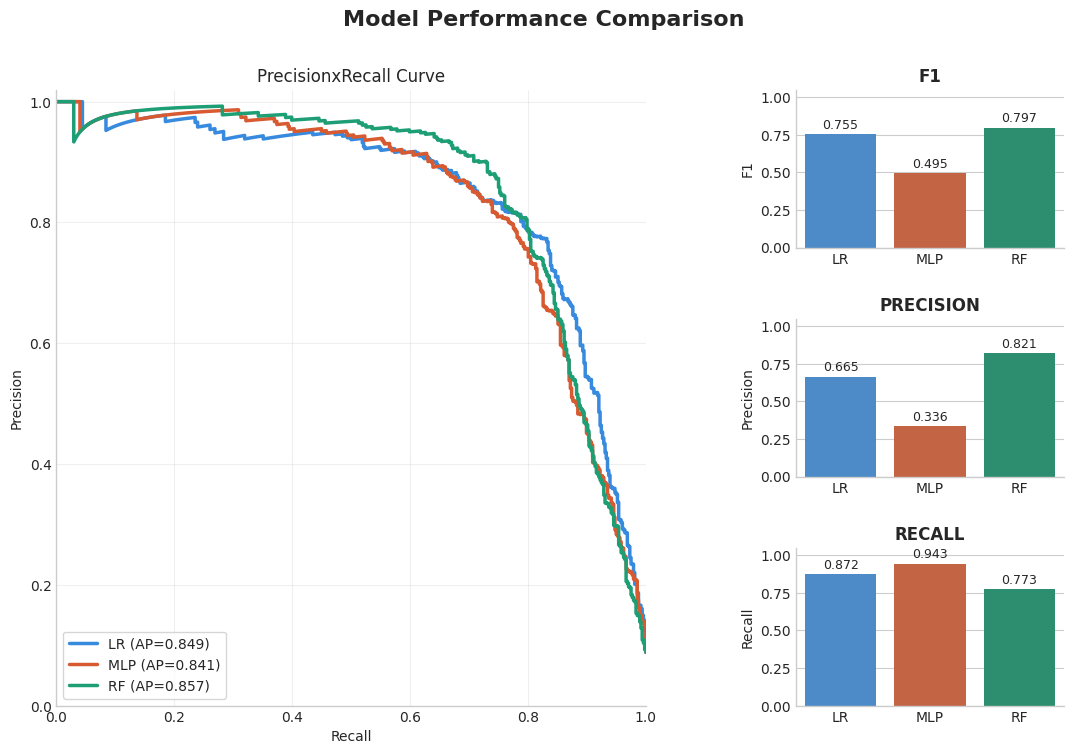

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

palette = {
            "LR": "#378ADD",
            "RF": "#1D9E75",
            "MLP": "#D85A30",
            "Logistic Regression": "#378ADD",
            "Random Forest": "#1D9E75",
        }


plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(13, 8))

gs = gridspec.GridSpec(
    3,
    2,
    width_ratios=[2.2, 1],
    wspace=0.35,
    hspace=0.45,
)

ax_pr = fig.add_subplot(gs[:, 0])

ax_f1 = fig.add_subplot(gs[0, 1])
ax_precision = fig.add_subplot(gs[1, 1], sharey=ax_f1)
ax_recall = fig.add_subplot(gs[2, 1], sharey=ax_f1)

plot_precision_recall(preds_nc2wp, 
                      ax=ax_pr, 
                      palette=palette,
                        title="PrecisionxRecall Curve",
                        legend=True)


plot_metric_bar(preds_nc2wp, "f1", ax=ax_f1)
plot_metric_bar(preds_nc2wp, "precision", ax=ax_precision)
plot_metric_bar(preds_nc2wp, "recall", ax=ax_recall)

fig.suptitle(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Plot cross validation results

In [ ]:
print(df_nc.groupby("model")[["threshold","recall","precision","f1"]].agg(["mean","std"]))

In [19]:
all_results[all_results["fold"] == "point"].groupby("model")[["threshold","recall","precision","f1"]].agg(["mean","std"])

NameError: name 'all_results' is not defined

In [81]:
all_results[all_results["fold"] == "point"].groupby("model")[["threshold","recall","precision","f1"]].agg(["mean","std"])

threshold              recall           precision                  f1  \
           mean       std      mean       std      mean       std      mean   
model                                                                         
LR     0.977064  0.028203  0.348921  0.252281  0.961397  0.054593  0.481249   
MLP    0.745000  0.134350  0.704130  0.308496  0.654097  0.378999  0.590417   
RF     0.879433  0.064750  0.035125  0.030544  0.982143  0.025254  0.066917   

                 
            std  
model            
LR     0.268523  
MLP    0.065181  
RF     0.056887

In [82]:
all_results[all_results["fold"] != "point"].groupby("model")[["threshold","recall","precision","f1"]].agg(["mean","std"])

threshold              recall           precision                  f1  \
           mean       std      mean       std      mean       std      mean   
model                                                                         
LR     0.977058  0.019962  0.349877  0.179485  0.961850  0.039967  0.482190   
MLP    0.744813  0.096078  0.703984  0.218009  0.655217  0.268248  0.591172   
RF     0.879442  0.045747  0.035769  0.025515  0.982083  0.031453  0.067836   

                 
            std  
model            
LR     0.190792  
MLP    0.050217  
RF     0.045786

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric_across_experiments(results, metric="pr_auc",
                                    experiment_order=("NC->NC","NC->WP","WP->WP","WP->NC"),
                                    figsize=(9,5)):
    """
    Boxplot for in-domain folds + bootstrap distribution for cross-domain,
    all on one axis. Shows the transfer gap directly.
    """
    df = results.copy()
    df = df[df["fold"] != "point"]   # keep folds + bootstrap draws
    df["experiment"] = pd.Categorical(df["experiment"],
                                       categories=list(experiment_order), ordered=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=df, x="experiment", y=metric, hue="model",
        order=list(experiment_order),
        palette={"LR":"#378ADD","RF":"#1D9E75","MLP":"#D85A30"},
        showfliers=False, ax=ax,
    )

    # overlay the "point" estimates for cross-domain as diamonds
    points = results[results["fold"] == "point"]
    for _, r in points.iterrows():
        ax.scatter(r["experiment"], r[metric], marker="D",
                   edgecolor="black", facecolor="white", zorder=5, s=40)

    ax.set_ylabel(metric.upper().replace("_"," "))
    ax.set_xlabel("")
    ax.set_ylim(0, 1.02)
    ax.axvline(1.5, ls="--", color="gray", alpha=0.5)  # visual divider in/cross domain
    ax.set_title(f"{metric.upper()} — in-domain (CV folds) vs cross-domain (bootstrap)")
    plt.tight_layout()
    return fig, ax

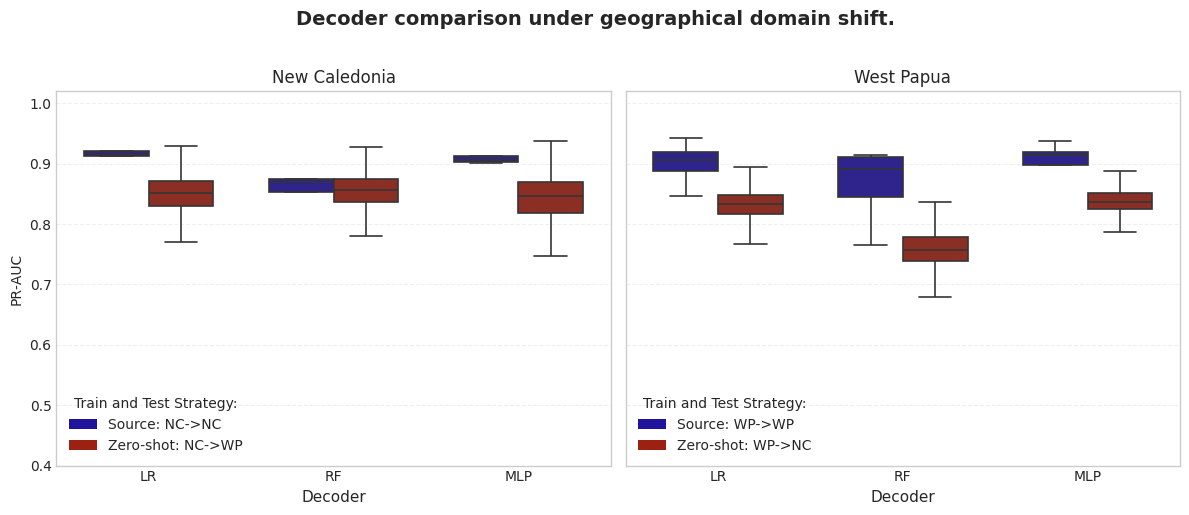

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch


df = all_results.copy()
dist_df = df[df["fold"] != "point"].copy()
point_df = df[df["fold"] == "point"].copy()

dist_df[["source", "target"]] = dist_df["experiment"].str.split("->", expand=True)
point_df[["source", "target"]] = point_df["experiment"].str.split("->", expand=True)

dist_df["shift"] = dist_df.apply(lambda r: "same" if r["source"] == r["target"] else "cross", axis=1)
point_df["shift"] = point_df.apply(lambda r: "same" if r["source"] == r["target"] else "cross", axis=1)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
source_order = ("NC", "WP")
source_name= ("New Caledonia","West Papua")
model_order = ["LR", "RF", "MLP"]
hue_order = ["same", "cross"]
shift_palette = {"same": "#20139C", "cross": "#9C2113"}   #palette

for ax, source,source_name in zip(axes, source_order, source_name):
    d = dist_df[dist_df["source"] == source]
    p = point_df[point_df["source"] == source]

    sns.boxplot(
        data=d,
        x="model", y="pr_auc", hue="shift",
        order=model_order,
        hue_order=hue_order,
        palette=shift_palette,
        showfliers=False,
        ax=ax,
        linewidth=1.2,
        width=0.7,
    )

    ax.set_title(f"{source_name}", fontsize=12, fontweight="normal")
    ax.set_xlabel("Decoder", fontsize=11)
    ax.set_ylabel("PR‑AUC" if ax == axes[0] else "")
    ax.set_ylim(0.4, 1.02)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # remove the default legend created by seaborn
    if ax.legend_ is not None:
        ax.legend_.remove()

# Create a custom legend on the right subplot (lower left)
legend_elements_0 = [
    Patch(facecolor=shift_palette["same"], label="Source: NC->NC"),
    Patch(facecolor=shift_palette["cross"], label="Zero-shot: NC->WP")
]
axes[0].legend(handles=legend_elements_0, loc='lower left', title="Train and Test Strategy:", framealpha=0.9)

legend_elements_1 = [
    Patch(facecolor=shift_palette["same"], label="Source: WP->WP"),
    Patch(facecolor=shift_palette["cross"], label="Zero-shot: WP->NC")
]
axes[1].legend(handles=legend_elements_1, loc='lower left', title="Train and Test Strategy:", framealpha=0.9)

fig.suptitle("Decoder comparison under geographical domain shift.", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

fig.savefig("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/"
            "models_run/ready_plots/decoder_comparison.pdf",
            format="pdf", 
            bbox_inches="tight"
            )

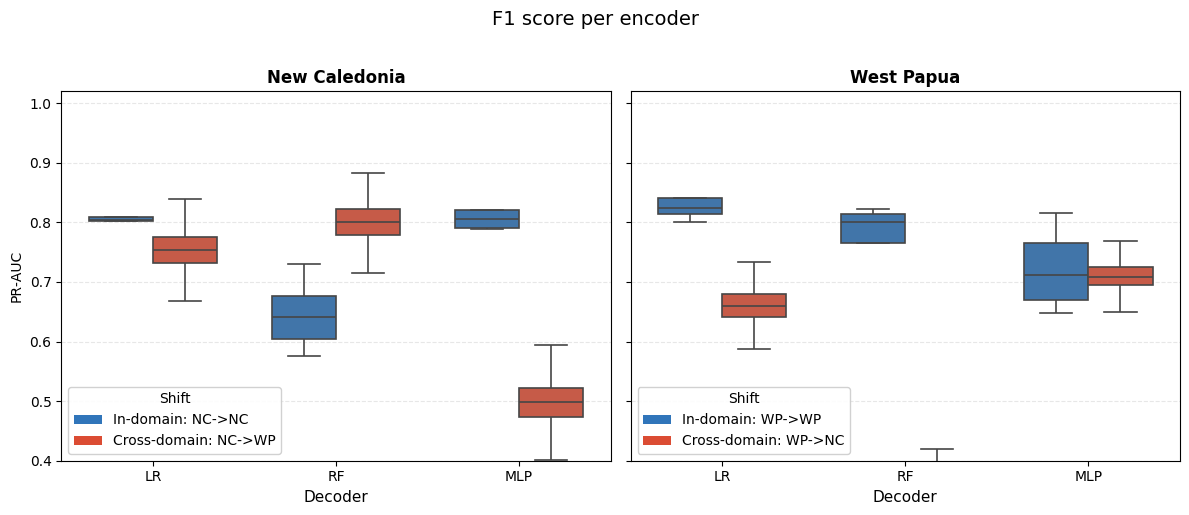

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch


df = all_results.copy()
dist_df = df[df["fold"] != "point"].copy()
point_df = df[df["fold"] == "point"].copy()

dist_df[["source", "target"]] = dist_df["experiment"].str.split("->", expand=True)
point_df[["source", "target"]] = point_df["experiment"].str.split("->", expand=True)

dist_df["shift"] = dist_df.apply(lambda r: "same" if r["source"] == r["target"] else "cross", axis=1)
point_df["shift"] = point_df.apply(lambda r: "same" if r["source"] == r["target"] else "cross", axis=1)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
source_order = ("NC", "WP")
source_name= ("New Caledonia","West Papua")
model_order = ["LR", "RF", "MLP"]
hue_order = ["same", "cross"]
shift_palette = {"same": "#3075BA", "cross": "#DB4C33"}   #palette

for ax, source,source_name in zip(axes, source_order, source_name):
    d = dist_df[dist_df["source"] == source]
    p = point_df[point_df["source"] == source]

    sns.boxplot(
        data=d,
        x="model", y="f1", hue="shift",
        order=model_order,
        hue_order=hue_order,
        palette=shift_palette,
        showfliers=False,
        ax=ax,
        linewidth=1.2,
        width=0.7,
    )

    # overlay point estimates (diamonds)
    # offset = 0.2
    # for _, row in p.iterrows():
    #     model_index = model_order.index(row["model"])
    #     x_base = model_index
    #     x_pos = x_base - offset if row["shift"] == "same" else x_base + offset
    #     ax.scatter(x_pos, row["pr_auc"], marker="D",
    #                edgecolor="black", facecolor="white",
    #                s=50, zorder=5)

    ax.set_title(f"{source_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Decoder", fontsize=11)
    ax.set_ylabel("PR‑AUC" if ax == axes[0] else "")
    ax.set_ylim(0.4, 1.02)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # remove the default legend created by seaborn
    if ax.legend_ is not None:
        ax.legend_.remove()

# Create a custom legend on the right subplot (lower left)
legend_elements_0 = [
    Patch(facecolor=shift_palette["same"], label="In-domain: NC->NC"),
    Patch(facecolor=shift_palette["cross"], label="Cross-domain: NC->WP")
]
axes[0].legend(handles=legend_elements_0, loc='lower left', title="Shift", framealpha=0.9)

legend_elements_1 = [
    Patch(facecolor=shift_palette["same"], label="In-domain: WP->WP"),
    Patch(facecolor=shift_palette["cross"], label="Cross-domain: WP->NC")
]
axes[1].legend(handles=legend_elements_1, loc='lower left', title="Shift", framealpha=0.9)

fig.suptitle("F1 score per encoder", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [112]:
df = all_results.copy()


In [118]:
all_results["experiment"].unique()

<ArrowStringArray>
['NC->NC', 'WP->WP', 'NC->WP', 'WP->NC']
Length: 4, dtype: str

ValueError: Could not interpret value `method` for `x`. An entry with this name does not appear in `data`.

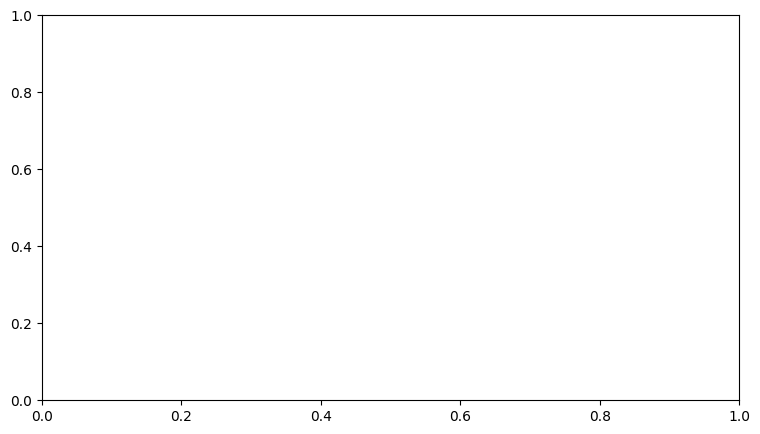

In [110]:
fig, ax = plot_metric_across_experiments(
    results,
    metric="f1",
    experiment_order=("NC->NC", "NC->WP", "WP->WP", "WP->NC"),
    figsize=(9,5)
)

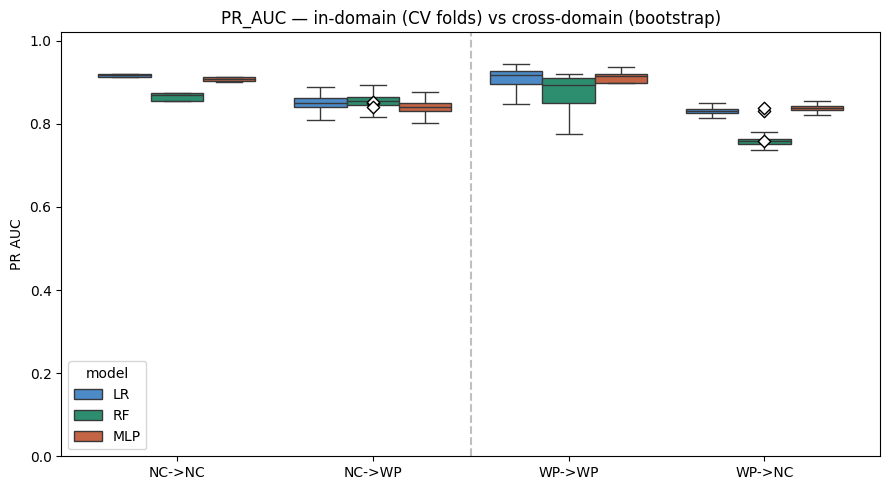

In [70]:
plot_metric_across_experiments(all_results, 
                               metric="pr_auc",
                                    experiment_order=("NC->NC","NC->WP","WP->WP","WP->NC"),
                                    figsize=(9,5))

plt.show()

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_transfer_gap_panels(
    results,
    metrics=("f1","precision","recall","roc_auc"),
    metric_labels=("F1","Precision","Recall","ROC-AUC"),
    directions=(("NC->NC","NC->WP"), ("WP->WP","WP->NC")),
    model_colors={"LR":"#378ADD","RF":"#1D9E75","MLP":"#D85A30"},
    figsize=(13, 5.5),
):
    df = results.copy()
    df["fold"] = df["fold"].astype(str)
    is_boot  = df["fold"].str.startswith("boot_")
    is_point = df["fold"] == "point"
    in_dom_df = df[~is_boot & ~is_point]
    boot_df   = df[is_boot]

    fig, axes = plt.subplots(1, len(directions), figsize=figsize,
                              sharey=True)

    x_metric = np.arange(len(metrics))           # metric group positions
    n_models = len(model_colors)
    width    = 0.22                              # spacing between models within a group

    for ax, (src_exp, tgt_exp) in zip(axes, directions):
        for i, (model, color) in enumerate(model_colors.items()):
            # x offset for this model within each metric group
            offset = (i - (n_models - 1) / 2) * width

            for j, m in enumerate(metrics):
                # in-domain: mean + std across folds
                in_sub = in_dom_df[(in_dom_df.experiment == src_exp) &
                                    (in_dom_df.model == model)]
                in_mean = in_sub[m].mean()
                in_std  = in_sub[m].std()

                # cross-domain: mean + 95% CI from bootstrap
                cr_sub = boot_df[(boot_df.experiment == tgt_exp) &
                                  (boot_df.model == model)]
                cr_mean = cr_sub[m].mean()
                cr_lo, cr_hi = np.percentile(cr_sub[m], [2.5, 97.5])

                xpos = x_metric[j] + offset

                # in-domain reference: short horizontal segment + light std band
                ax.hlines(in_mean, xpos - width*0.45, xpos + width*0.45,
                          color=color, linestyle="--", linewidth=1.8, alpha=0.9)
                ax.add_patch(plt.Rectangle(
                    (xpos - width*0.45, in_mean - in_std),
                    width*0.9, 2*in_std,
                    color=color, alpha=0.10, linewidth=0,
                ))

                # cross-domain: point with 95% CI error bar
                ax.errorbar(
                    xpos, cr_mean,
                    yerr=[[cr_mean - cr_lo], [cr_hi - cr_mean]],
                    fmt="o", color=color, ecolor=color,
                    capsize=4, markersize=6,
                    markerfacecolor="white", markeredgewidth=1.8,
                )

        ax.set_xticks(x_metric)
        ax.set_xticklabels(metric_labels)
        ax.set_title(f"{src_exp.replace('->','→')} baseline  vs  "
                     f"{tgt_exp.replace('->','→')} transfer",
                     fontsize=11)
        ax.set_ylim(0, 1.02)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Score")

    # single legend: model colors + line/marker meaning
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    model_handles = [Line2D([0],[0], color=c, lw=2.5, label=m)
                     for m, c in model_colors.items()]
    style_handles = [
        Line2D([0],[0], color="gray", ls="--", lw=1.8, label="In-domain mean (CV folds)"),
        Patch(facecolor="gray", alpha=0.15, label="In-domain ±1 std"),
        Line2D([0],[0], marker="o", color="gray", markerfacecolor="white",
               markeredgewidth=1.8, lw=0, label="Cross-domain mean ± 95% CI"),
    ]
    fig.legend(handles=model_handles + style_handles,
               loc="lower center", ncol=6, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    return fig, axes

In [85]:
(all_results[all_results["fold"] != "point"]
 .groupby(["experiment","model"])[["threshold","recall","precision","f1"]]
 .agg(["mean","std"])
 .round(3))

threshold        recall        precision            f1       
                      mean    std   mean    std      mean    std   mean    std
experiment model                                                              
NC->NC     LR        0.959  0.021  0.486  0.059     0.993  0.008  0.651  0.053
           MLP       0.532  0.186  0.809  0.064     0.837  0.023  0.822  0.040
           RF        0.857  0.026  0.202  0.104     1.000  0.000  0.326  0.143
NC->WP     LR        0.957  0.000  0.528  0.024     0.923  0.016  0.671  0.021
           MLP       0.650  0.000  0.922  0.012     0.386  0.014  0.544  0.015
           RF        0.834  0.000  0.057  0.011     0.964  0.037  0.107  0.019
WP->NC     LR        0.997  0.000  0.171  0.008     1.000  0.000  0.291  0.012
           MLP       0.840  0.000  0.486  0.011     0.922  0.008  0.636  0.010
           RF        0.925  0.000  0.014  0.002     1.000  0.000  0.027  0.005
WP->WP     LR        0.996  0.002  0.490  0.112     0.982  0.016  0.648  0.102
           MLP       0.918  0.024  0.786  0.096     0.894  0.060  0.832  0.051
           RF        0.913  0.003  0.177  0.038     1.000  0.000  0.299  0.054

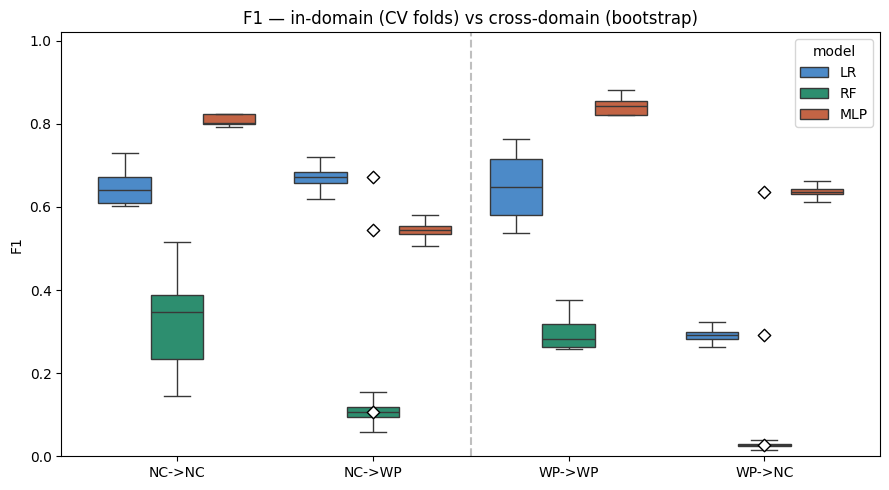

In [74]:
plot_metric_across_experiments(all_results, 
                               metric="f1",
                                    experiment_order=("NC->NC","NC->WP","WP->WP","WP->NC"),
                                    figsize=(9,5))

plt.show()

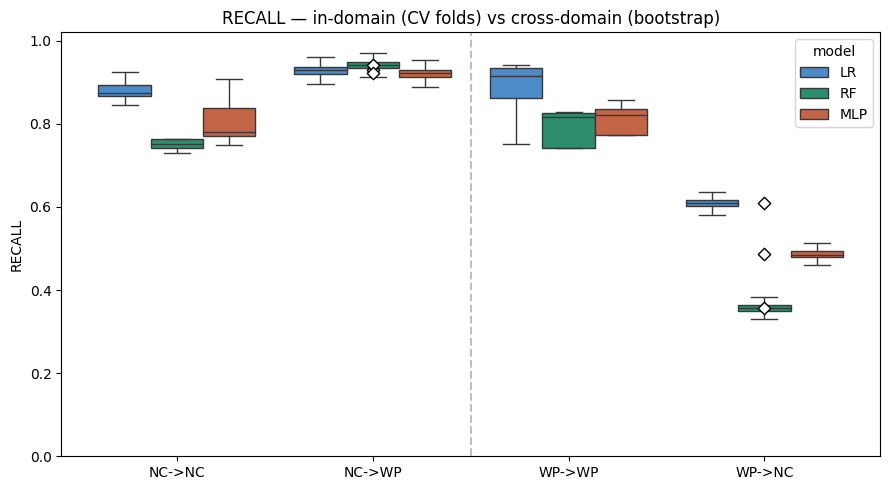

In [40]:
plot_metric_across_experiments(all_results, 
                               metric="recall",
                                    experiment_order=("NC->NC","NC->WP","WP->WP","WP->NC"),
                                    figsize=(9,5))

plt.show()

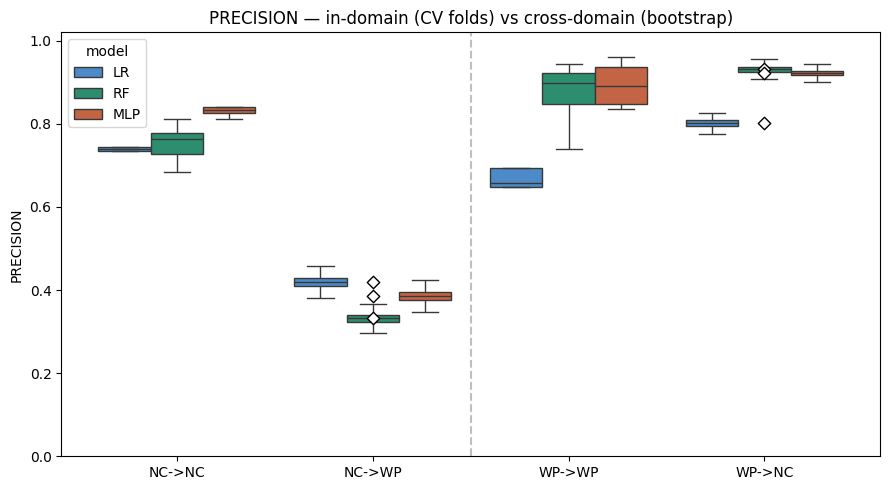

In [41]:
plot_metric_across_experiments(all_results, 
                               metric="precision",
                                    experiment_order=("NC->NC","NC->WP","WP->WP","WP->NC"),
                                    figsize=(9,5))

plt.show()

In [39]:
def plot_transfer_gaps(results, metric="pr_auc"):
    in_domain = (results[(results["fold"] != "point") &
                          (~results["fold"].str.startswith("boot_"))]
                 .groupby(["experiment","model"])[metric].mean())

    cross_point = (results[results["fold"] == "point"]
                   .set_index(["experiment","model"])[metric])

    pairs = [("NC->NC", "NC->WP"), ("WP->WP", "WP->NC")]
    rows = []
    for src_exp, tgt_exp in pairs:
        for model in results["model"].unique():
            gap = in_domain[(src_exp, model)] - cross_point[(tgt_exp, model)]
            rows.append({"direction": tgt_exp, "model": model, "gap": gap})
    gaps = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(7,4))
    sns.barplot(data=gaps, x="direction", y="gap", hue="model",
                palette={"LR":"#378ADD","RF":"#1D9E75","MLP":"#D85A30"}, ax=ax)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel(f"{metric.upper()} drop (in-domain − cross-domain)")
    ax.set_title("Transfer gap by direction")
    plt.tight_layout()
    return fig, ax

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Transfer gap by direction'}, xlabel='direction', ylabel='PR_AUC drop (in-domain − cross-domain)'>)

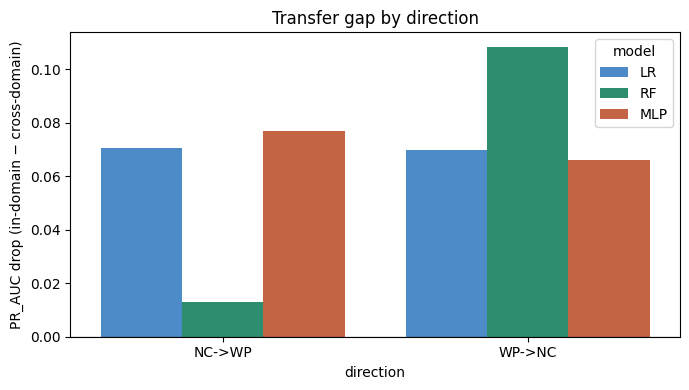

In [40]:
plot_transfer_gaps(all_results,metric="pr_auc")

In [92]:
def plot_pr_grid(preds_df, experiments=("NC->NC","NC->WP","WP->WP","WP->NC")):
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, exp in zip(axes.ravel(), experiments):
        sub = preds_df[preds_df["experiment"] == exp]
        if sub.empty: continue
        plot_precision_recall(sub, ax=ax)
        ax.set_title(exp)
    plt.tight_layout()
    return fig, axes

NameError: name 'plot_precision_recall' is not defined

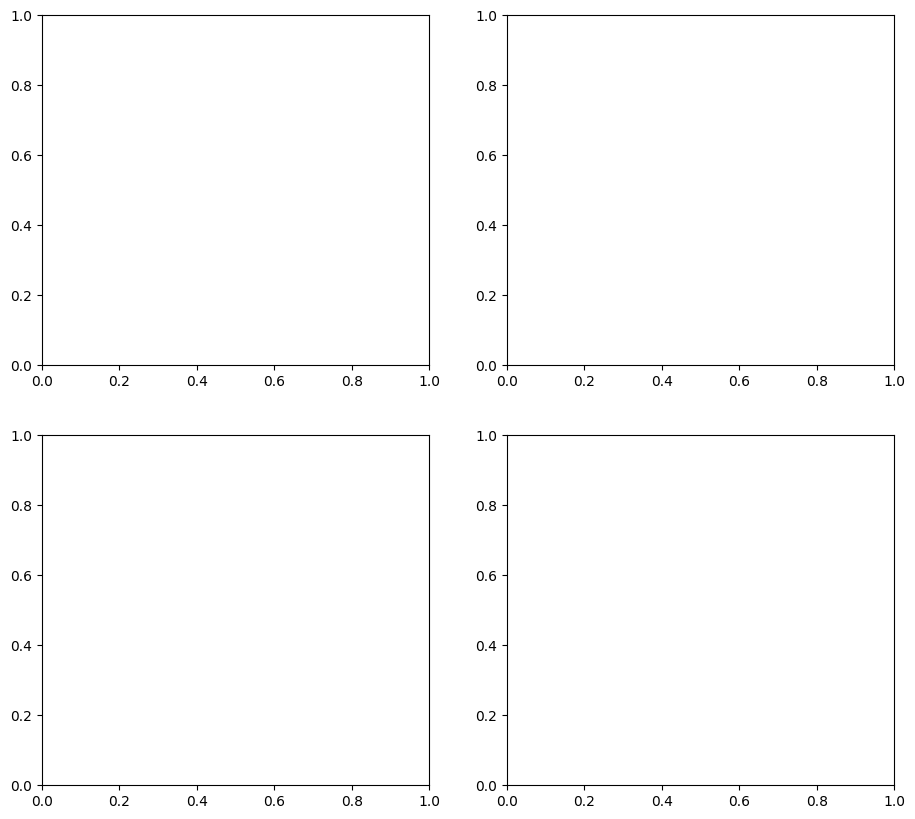

In [93]:
plot_pr_grid(all_results)

In [94]:
import pandas as pd
import numpy as np

def summarize_for_latex(results, metrics=("f1","precision","recall","roc_auc")):
    """
    Build a wide table: rows = experiment, columns = (model, metric),
    values = 'mean ± std'. In-domain uses fold rows; cross-domain uses
    bootstrap rows (excluding the 'point' row).
    """
    df = results.copy()

    # tag in-domain vs cross-domain by which folds carry variance
    is_boot  = df["fold"].astype(str).str.startswith("boot_")
    is_point = df["fold"].astype(str) == "point"

    # in-domain = numeric fold labels; cross-domain = bootstrap rows only
    in_dom  = df[~is_boot & ~is_point]
    cross   = df[is_boot]
    df_var  = pd.concat([in_dom, cross], ignore_index=True)

    # aggregate
    agg = (df_var
           .groupby(["experiment","model"])[list(metrics)]
           .agg(["mean","std"]))

    # format 'mean ± std' with 3 decimals
    def fmt(mean, std):
        if pd.isna(mean): return "--"
        return f"{mean:.3f} $\\pm$ {std:.3f}"

    formatted = pd.DataFrame(index=agg.index)
    for m in metrics:
        formatted[m] = [fmt(mu, sd) for mu, sd in zip(agg[(m,"mean")], agg[(m,"std")])]

    # pivot to wide: rows = experiment, columns = (model, metric)
    wide = formatted.unstack("model")
    # reorder: model outer, metric inner
    wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)

    # fix row + column order
    exp_order   = ["NC->NC","WP->WP","NC->WP","WP->NC"]
    model_order = ["LR","RF","MLP"]
    metric_order = list(metrics)
    wide = wide.reindex(index=[e for e in exp_order if e in wide.index])
    wide = wide.reindex(columns=pd.MultiIndex.from_product([model_order, metric_order]))

    return wide

table = summarize_for_latex(all_results)
print(table)

# emit LaTeX body rows directly
latex = table.to_latex(
    escape=False,          # keep the ± math
    multicolumn=True,
    multicolumn_format="c",
    column_format="l" + "cccc"*3,
)
print(latex)

                           LR                                        \
                           f1          precision             recall   
experiment                                                            
NC->NC      0.809 $\pm$ 0.032  0.817 $\pm$ 0.026  0.803 $\pm$ 0.046   
WP->WP      0.839 $\pm$ 0.049  0.836 $\pm$ 0.082  0.851 $\pm$ 0.084   
NC->WP      0.621 $\pm$ 0.015  0.474 $\pm$ 0.016  0.904 $\pm$ 0.013   
WP->NC      0.661 $\pm$ 0.010  0.884 $\pm$ 0.009  0.528 $\pm$ 0.011   

                                              RF                     \
                      roc_auc                 f1          precision   
experiment                                                            
NC->NC      0.943 $\pm$ 0.016  0.646 $\pm$ 0.061  0.957 $\pm$ 0.030   
WP->WP      0.976 $\pm$ 0.017  0.784 $\pm$ 0.069  0.954 $\pm$ 0.027   
NC->WP      0.966 $\pm$ 0.004  0.797 $\pm$ 0.014  0.822 $\pm$ 0.018   
WP->NC      0.867 $\pm$ 0.005  0.219 $\pm$ 0.011  1.000 $\pm$ 0.000   

    

In [95]:
def compute_transfer_gaps(results, metrics=("f1","precision","recall","roc_auc")):
    df = results.copy()
    is_boot  = df["fold"].astype(str).str.startswith("boot_")
    is_point = df["fold"].astype(str) == "point"

    in_dom = df[~is_boot & ~is_point]
    cross  = df[is_boot]

    in_mean    = in_dom.groupby(["experiment","model"])[list(metrics)].mean()
    cross_mean = cross.groupby(["experiment","model"])[list(metrics)].mean()

    pairs = [("NC->NC","NC->WP"), ("WP->WP","WP->NC")]
    rows = []
    for src_exp, tgt_exp in pairs:
        for model in ["LR","RF","MLP"]:
            row = {"direction": tgt_exp.replace("->","$\\to$"), "model": model}
            for m in metrics:
                v_in    = in_mean.loc[(src_exp, model), m]
                v_cross = cross_mean.loc[(tgt_exp, model), m]
                delta   = v_in - v_cross
                row[f"{m}_in"]    = f"{v_in:.3f}"
                row[f"{m}_cross"] = f"{v_cross:.3f}"
                # bold the big drops (> 0.10)
                if delta > 0.10:
                    row[f"{m}_delta"] = f"\\textbf{{+{delta:.3f}}}"
                elif delta < -0.10:
                    row[f"{m}_delta"] = f"$-{abs(delta):.3f}$"
                else:
                    sign = "+" if delta >= 0 else "$-$"
                    row[f"{m}_delta"] = f"{sign}{abs(delta):.3f}"
            rows.append(row)

    return pd.DataFrame(rows)

gap_table = compute_transfer_gaps(all_results)
print(gap_table.to_string(index=False))

direction model f1_in f1_cross        f1_delta precision_in precision_cross precision_delta recall_in recall_cross    recall_delta roc_auc_in roc_auc_cross   roc_auc_delta
NC$\to$WP    LR 0.809    0.621 \textbf{+0.188}        0.817           0.474 \textbf{+0.343}     0.803        0.904        $-0.101$      0.943         0.966        $-$0.023
NC$\to$WP    RF 0.646    0.797        $-0.151$        0.957           0.822 \textbf{+0.134}     0.491        0.774        $-0.283$      0.895         0.962        $-$0.067
NC$\to$WP   MLP 0.822    0.544 \textbf{+0.278}        0.837           0.386 \textbf{+0.451}     0.809        0.922        $-0.113$      0.939         0.964        $-$0.025
WP$\to$NC    LR 0.839    0.661 \textbf{+0.178}        0.836           0.884        $-$0.048     0.851        0.528 \textbf{+0.323}      0.976         0.867 \textbf{+0.109}
WP$\to$NC    RF 0.784    0.219 \textbf{+0.565}        0.954           1.000        $-$0.046     0.671        0.123 \textbf{+0.548}      0.96